# Neurotransmitter Probability Variance across Drosophila Neuropils

This projects aims to answer - how do neurotransmitter probability distributions vary across neuropils in Drosophila?
The datasets should be downloaded into the data directory following the instructions on GitHub. 

This notebook is not fully complete. I could not implement the brain map section and integrate the statistical analysis within my deadline.

## Stage 0: Set up environment

In [1]:
%load_ext autoreload 
%autoreload 2

# Import external libraries
import dask
from IPython.core.display import HTML, Image
from IPython.display import IFrame
from dask.distributed import Client

# Import core python libraries
import os

# Import local scripts (brainz.py, pipeline.py, plotting.py, 
# preprocess.py)
from scripts import *

In [2]:
# Set globals
OUTDIR = os.path.join(os.path.dirname(__name__), "results", "notebook")
if not os.path.exists(OUTDIR): os.mkdir(OUTDIR)
MINSIZE = 30 # Minimum number of nodes in a cluster/community

In [3]:
allow_bytes = pipeline.get_ram_allowance() # Allow Dask to use just over 60% of system RAM
PARTITION_SIZE = pipeline.get_partition_size(num_threads = 4, allow_bytes = allow_bytes)
client = pipeline.start_dask(num_threads = 4, allow_bytes = allow_bytes)
dask.config.set({"dataframe.shuffle.method": "tasks"})
preprocess.run() # ~10 mins first run

15.8 GiB available on machine; allowing 9.5 GiB

Dask Dashboard at http://192.168.0.134:8787/status

Notice: this may take some time if this is the first time running preprocess.py.


17:56:52 Preprocessing complete!


2026-06-01 18:00:21,531 - distributed.worker.memory - WARNING - Worker is at 82% memory usage. Pausing worker.  Process memory: 7.82 GiB -- Worker memory limit: 9.48 GiB
2026-06-01 18:00:21,979 - distributed.worker.memory - WARNING - Worker is at 78% memory usage. Resuming worker. Process memory: 7.40 GiB -- Worker memory limit: 9.48 GiB
2026-06-01 18:01:24,297 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  Process memory: 7.87 GiB -- Worker memory limit: 9.48 GiB
2026-06-01 18:01:25,416 - distributed.worker.memory - WARNING - Worker is at 78% memory usage. Resuming worker. Process memory: 7.41 GiB -- Worker memory limit: 9.48 GiB
2026-06-01 18:01:29,546 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 7.69 GiB -- Worker memory limit: 9.48 GiB
2026-06-01 18:01:29,959 - distributed.worker.memory - WARNING - Worker is at 78% memory usage. Resuming worker. Process memory: 7.47 GiB -- Worker mem

## Stage 1: Load Data

This stage of the pipeline loads and merges data from file, creating a single cohesive dataframe containing metadata for every synapse belonging to a neuron-neuron connection in proofread_connections_783.parquet. 

Neurotransmitter probability normalisation is required because the probabilities of some points do not sum to exactly 1 across all 6 neurotransmitters, but Dirichlet regression and composition analysis requires these probabilities to sum to exactly 1. Additionally, neurotransmitter normalisation reduces the data from 6 compositional variables to 3 compositional variables: GABA, an inhibitory neurotransmitter; Acetylcholine ('ach'), an excitatory neurotransmitter, and 'other', which encompasses the remaining neurotransmitters which cannot be reliably classified as solely inhibitory or excitatory (rather, they are usually neuromodulators).

Although the proofread connections file contains a compact representation of synapse data already (synapse count, and the same neurotransmitter probabilities allocated to each synapse), this stage of the pipeline expands the compact representation back to representing one synapse per row. This is because compositional analysis of neurotransmitter probabilities across synapses (e.g., in Dirichlet regression and in plotting ternary plots) requires this expanded format. 

In [4]:
# Choose dataset to use. Note the decisions made in this notebook are based
# on the full connectome dataset (proofread_connections_783.parquet). The
# other datasets are selections of different neuropils, and are provided for
# debugging/testing purposes.

DATASET = "data/proofread_connections_783.parquet" # ~ 1.05 GB

#DATASET = "data/large.parquet" # ~ 583 MB
#DATASET = "data/medium.parquet" # ~ 272 MB
#DATASET = "data/small.parquet" # ~ 56 MB
#DATASET = "data/tiny.parquet" # ~ 215 KB

In [5]:
pipeline.relax_memory_limits() # Let Dask use a higher percentage of allocated RAM

In [6]:
connectome = pipeline.load_connectome(DATASET, PARTITION_SIZE)
connectome.head(3, npartitions=1).style.hide(axis="index")

17:56:53 Loading connectome ...
17:57:11 Connectome loaded


pre,post,neuropil,gaba,ach,glut,oct,ser,da
720575940629970489,720575940631267655,AVLP_R,0.654330,0.023704,0.272418,0.048125,0.000472,0.000951
720575940623828999,720575940612348950,SLP_R,0.386517,0.024020,0.580512,0.000817,0.000857,0.007278
720575940624078484,720575940616950161,SMP_R,0.001719,0.979256,0.001811,0.000016,0.005870,0.011328


In [7]:
connectome = pipeline.normalise_nt_probs(connectome)
connectome.head(3, npartitions=1).style.hide(axis="index")

17:57:19 Normalising neurotransmitter probabilities ...
17:57:20 Neurotransmitter probabilities normalised


pre,post,neuropil,gaba,ach,other
720575940629970489,720575940631267655,AVLP_R,0.654330,0.023704,0.321967
720575940623828999,720575940612348950,SLP_R,0.386517,0.024020,0.589463
720575940624078484,720575940616950161,SMP_R,0.001719,0.979256,0.019025


In [8]:
# This step takes a little longer because it merges the 1 GB 
# proofread_synapses_783.parquet file with the ~13 GB 
# flywire_synapses_783.parquet file. 
# Took ~2 min with ~8 GB RAM allowance and 4 threads.
connectome = pipeline.attach_synapse_coords(connectome, PARTITION_SIZE)
connectome.head(3, npartitions=1).style.hide(axis="index")

17:57:38 Attaching coordinates ...


C:\Users\cielb\anaconda3\envs\nta3\Lib\site-packages\dask\dataframe\dask_expr\_collection.py:318: UserWarning: Dask annotations {'resources': {'shuffle': 1}} detected. Annotations will be ignored when using query-planning.
  warnings.warn(


17:59:12 Coordinates attached


index,pre,post,neuropil,gaba,ach,other,x,y,z
0,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,881336,509456,111960
1,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,852464,515064,84360
2,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,872544,515156,108480


In [9]:
connectome = pipeline.attach_neuropil_metadata(connectome)
connectome.head(3, npartitions=1).style.hide(axis="index")

18:03:48 Attaching neuropil metadata ...
18:04:55 Neuropil metadata attached


index,pre,post,neuropil,gaba,ach,other,x,y,z,region,neuropil_desc
0,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,881336,509456,111960,Gnathal Ganglia,gnathal ganglia
1,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,852464,515064,84360,Gnathal Ganglia,gnathal ganglia
2,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,872544,515156,108480,Gnathal Ganglia,gnathal ganglia


In [10]:
pipeline.restore_memory_limits() # Next stages are heavy on unmanaged memory

## Stage 2: Identify & Visualise Neurotransmitter Clusters

This step identifies frequent cluster compositions and allocates each point to either a frequent cluster or labels it as 'noise'. A brain map is then plotted, with each point's colour corresponding to its allocated neurotransmitter cluster. Although this approach requires extra effort and will be harder to automate in the future, it is superior to the naive approach of labelling each point on a brain map by the neurotransmitter with the highest probability for that edge. This is because the latter approach ignores important compositional information and can lump two very different neurotransmitter ratios into the same group (e.g., a point with 100% acetylcholine probability would be labelled in the same manner as a point with 34% acetylcholine, 33% gaba, and 33% other probabilities).

### Visualise Initial Neurotransmitter Probability Distribution

In [11]:
connectome_nts = connectome[["gaba", "ach", "other"]]

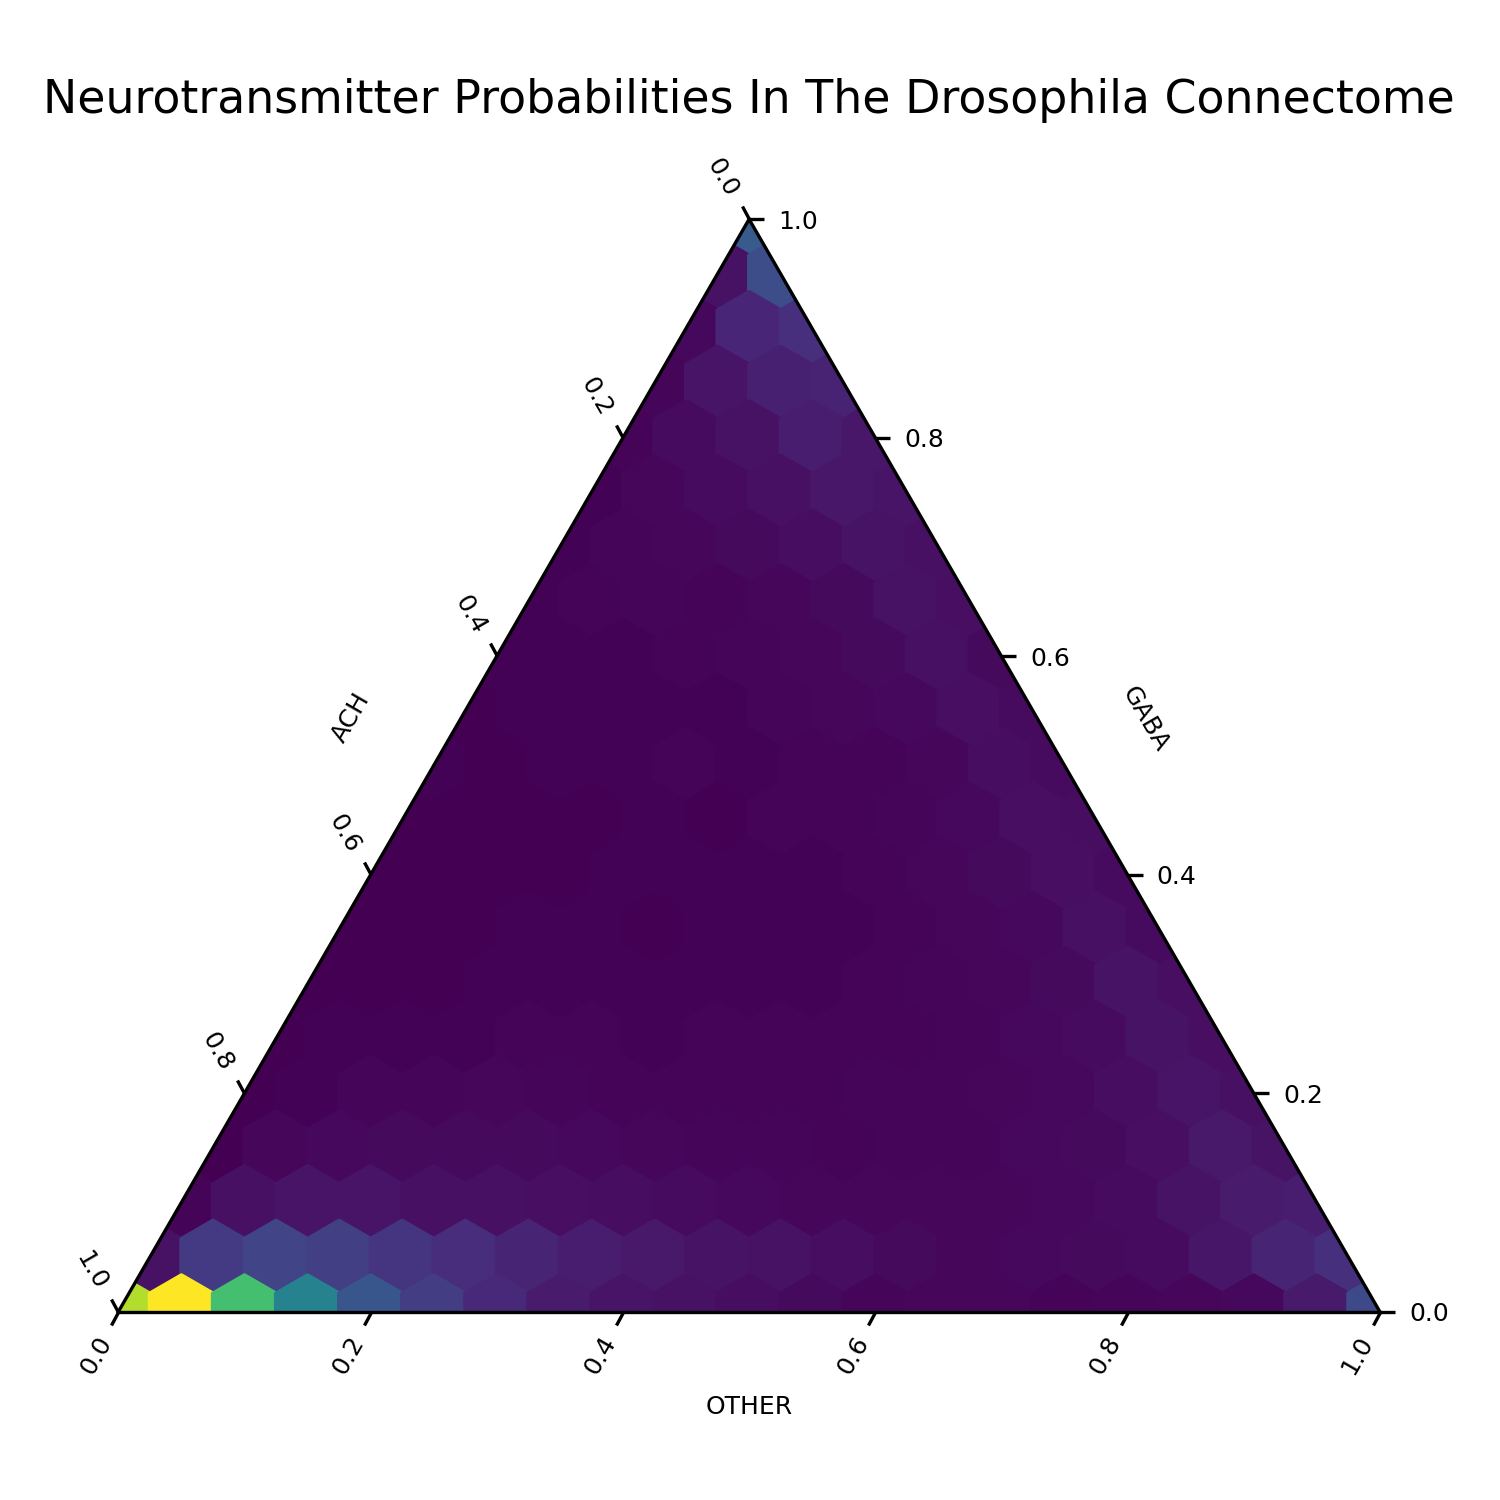

In [12]:
# Sample connectome - hexbin plotting is memory-intensive and don't need every data point to get idea of distribution
sample = pipeline.downsample(connectome_nts, 50_000, allow_bytes)
filename = os.path.join(OUTDIR, "init_overall_distribution.png")
pipeline.make_plot("plot_n_ternary", filename, samples = [sample], labels = ["Neurotransmitter_Probabilities_In_The_Drosophila_Connectome"])
Image(filename, width = 600)

### Divide synapses into 4 initial categories

The above ternary plot shows that the majority of synapses can be categorised as high ACH. Additionally, some can be categorised as high GABA and some as high OTHER. It does appear there may be some synapses that cannot be easily classified into any of these three corner categories. I will classify these as 'unclassified' for now. See the tag_clusters() function in the pipeline script for my choice of cluster boundaries. Note the results may vary slightly with slightly different boundaries.

In [13]:
# Extract and visualise the four initial clusters
connectome = pipeline.tag_clusters(connectome)
sample = pipeline.downsample(connectome, 50_000, allow_bytes)

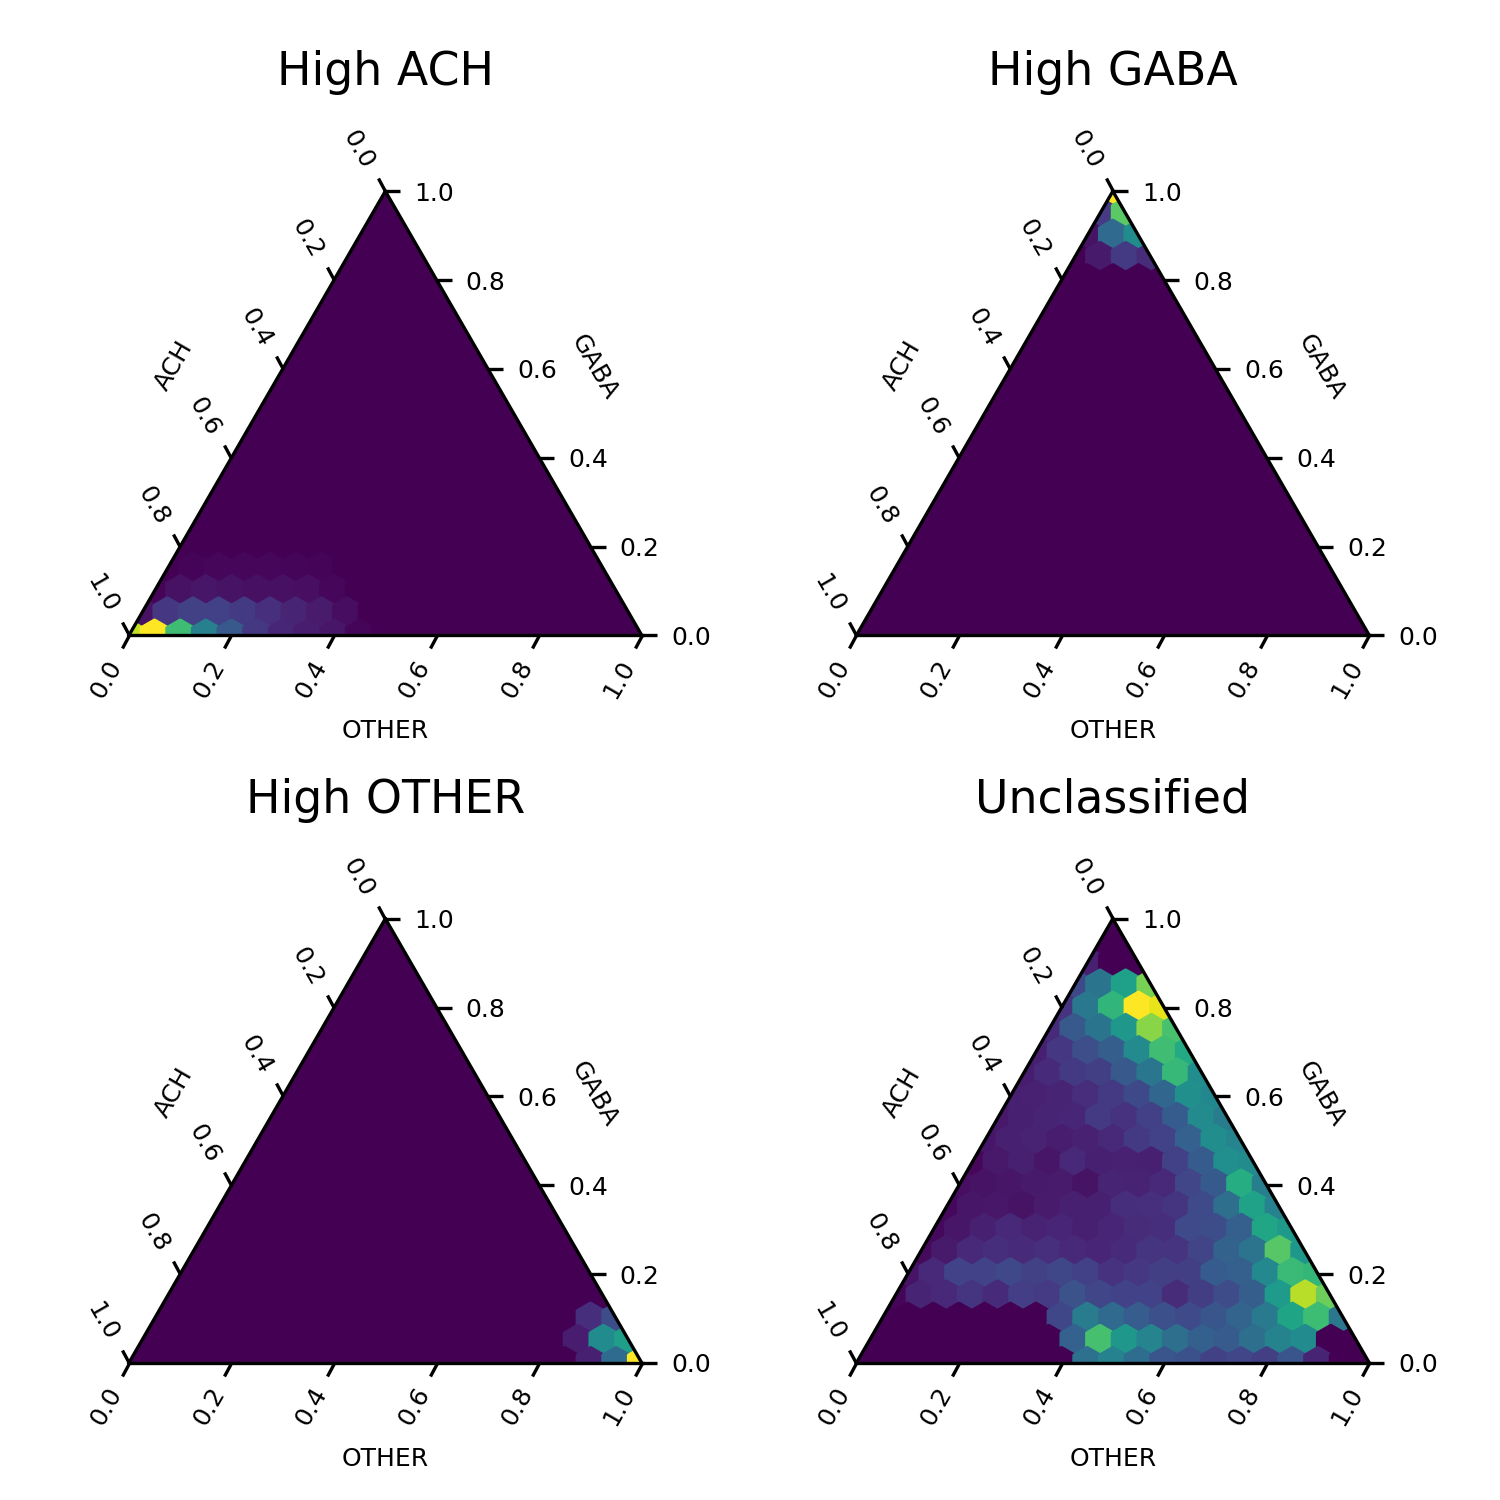

In [14]:
# Plot hex plots of new cluster classifications
grouped = sample.groupby("cluster")
high_gaba_sample = grouped.get_group("gaba")
high_ach_sample = grouped.get_group("ach")
high_other_sample = grouped.get_group("other")
unclassified_sample = grouped.get_group("none")

filename = os.path.join(OUTDIR, "initial_clusters.png")
pipeline.make_plot("plot_n_ternary", filename, 
                   samples = [high_gaba_sample, high_ach_sample, high_other_sample, unclassified_sample], 
                   labels = ["High_GABA", "High_ACH", "High_OTHER", "Unclassified"])
Image(filename, width = 600)

Filtering out the dense regions of the initial distribution reveals an interesting pattern that was previously obscured in unclassified synapses. Most unclassified synapses have ACH < 0.15 or GABA < 0.15. In the context of the dataset, synapse neurotransmitter probabilities not within these ranges are likely due to uncertainty in classification more so than biological significance. Synapses within these ranges may or may not be due to uncertainty as well. Regardless of cause, it will still be interesting to subdivide the unclassified synapses into 3 further categories for further analysis.

### Divide 'Unclassified' Into 3 Further Subdivisions

In [15]:
# Classify unclassified synapses into gaba_noise, ach_noise, and noise.
# Taking a larger sample this time because I want more power in my analysis.
connectome = pipeline.tag_unclassified_clusters(connectome)
print("All synapses tagged!")
sample = pipeline.downsample(connectome, 500_000, allow_bytes)

All synapses tagged!


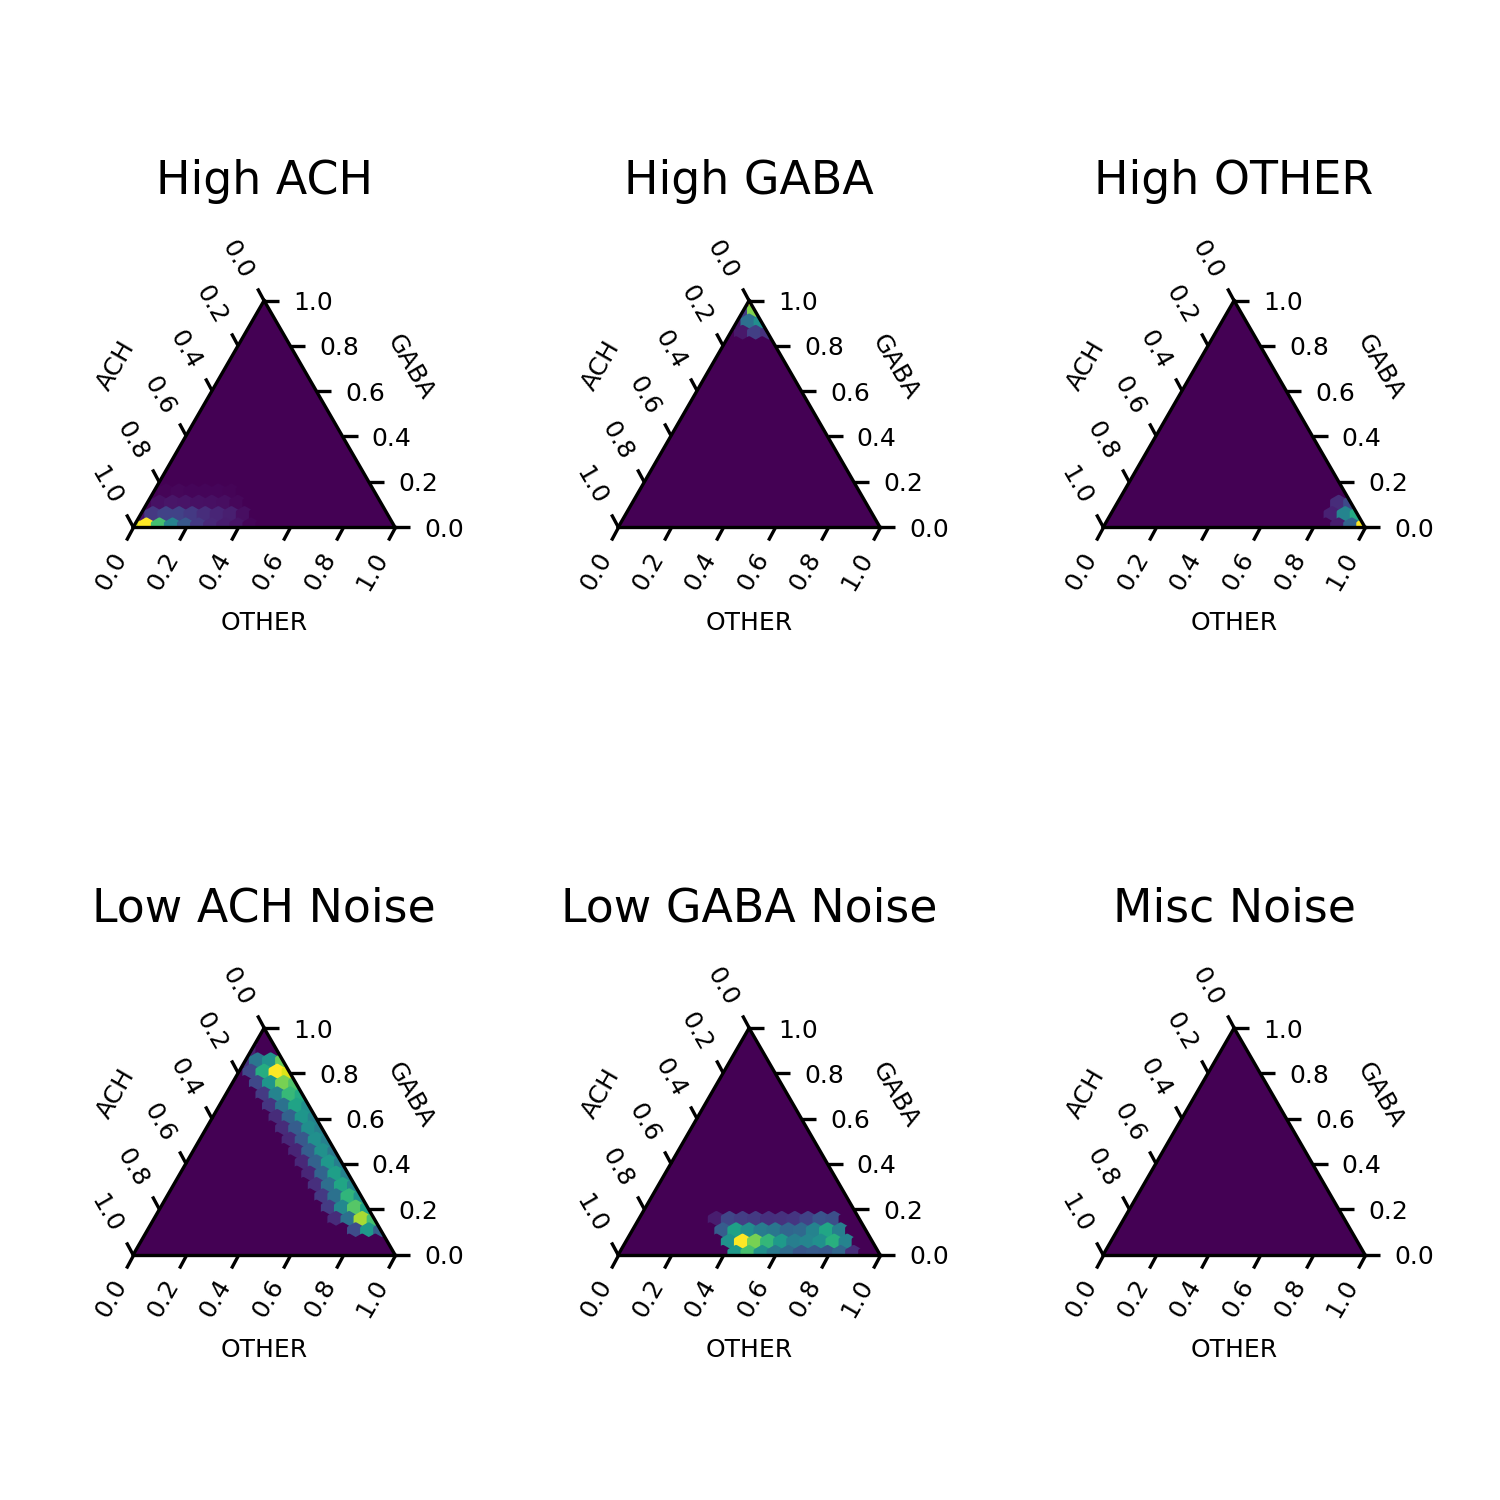

In [16]:
# Plot hex plots of new cluster classifications
grouped = sample.groupby("cluster")
high_gaba_sample = grouped.get_group("gaba")
high_ach_sample = grouped.get_group("ach")
high_other_sample = grouped.get_group("other")
low_ach_noise_sample = grouped.get_group("low_ach_noise")
low_gaba_noise_sample = grouped.get_group("low_gaba_noise")
misc_noise_sample = grouped.get_group("misc_noise")

filename = os.path.join(OUTDIR, "final_clusters.png")
pipeline.make_plot("plot_n_ternary", filename, 
                   samples = [high_gaba_sample, high_ach_sample, high_other_sample, 
                              low_ach_noise_sample, low_gaba_noise_sample, misc_noise_sample], 
                   labels = ["High_GABA", "High_ACH", "High_OTHER",
                             "Low_ACH_Noise", "Low_GABA_Noise", "Misc_Noise"])
Image(filename, width = 600)

I will use the same data points to generate the brain map as are used to generate the above 6 hex plots. These points will also be used downstream for statistical analysis, so will save to temp file for convenience.

In [17]:
sample_path = pipeline.make_temp_path()
sample.to_parquet(sample_path) # Create folder containing 1 parquet file per partition

## Stage 3: Report & Visualise Neurotransmitter Probability Distributions Across Neuropils

### Summary Statistics For Each Neuropil

In [18]:
neuropils = pipeline.get_neuropil_summary_stats(connectome)
filename = os.path.join(OUTDIR, "neuropil_summaries.csv")
neuropils = neuropils.compute()
neuropils.to_csv(filename)
print(neuropils)

18:35:05 Aggregating neuropil data ...
18:41:43 Neuropil data aggregated
           index  neuropil_size  region  neuropil_desc  cluster  gaba_mean  \
neuropil                                                                     
AL_L      835543         835543  835543         835543   835543   0.198715   
AL_R      854877         854877  854877         854877   854877   0.200653   
AME_L      33753          33753   33753          33753    33753   0.244209   
AME_R      35420          35420   35420          35420    35420   0.199794   
AMMC_L    286248         286248  286248         286248   286248   0.388338   
...          ...            ...     ...            ...      ...        ...   
UNASGD     20155          20155   20155          20155    20155   0.188382   
VES_L     773079         773079  773079         773079   773079   0.263695   
VES_R     844178         844178  844178         844178   844178   0.254214   
WED_L     690515         690515  690515         690515   690515   0.2

### Neuropil Neurotransmitter Probability Distributions By Region

In [19]:
grouped_regions = sample.groupby("region")
regions = list(sample["region"].unique().compute())
for region in regions:
    df = grouped_regions.get_group(region)
    filename = os.path.join(OUTDIR, f"Neuropil Distributions {region}.png")
    print(filename)
    pipeline.make_plot("plot_neuropils_in_region", filename,
                      samples = [df], labels = [region])

results\notebook\Neuropil Distributions Ventromedial Neuropils.png
results\notebook\Neuropil Distributions Mushroom Body.png
results\notebook\Neuropil Distributions Other Regions.png
results\notebook\Neuropil Distributions Optic Lobe.png
results\notebook\Neuropil Distributions Ocelli.png
results\notebook\Neuropil Distributions Antennal Lobe.png
results\notebook\Neuropil Distributions Periesophageal Neuropils.png
results\notebook\Neuropil Distributions Inferior Neuropils.png
results\notebook\Neuropil Distributions Lateral Complex.png
results\notebook\Neuropil Distributions Superior Neuropils.png
results\notebook\Neuropil Distributions Ventrolateral Neuropils.png
results\notebook\Neuropil Distributions Gnathal Ganglia.png
results\notebook\Neuropil Distributions Lateral Horn.png
results\notebook\Neuropil Distributions Central Complex.png


#### Optic Lobe

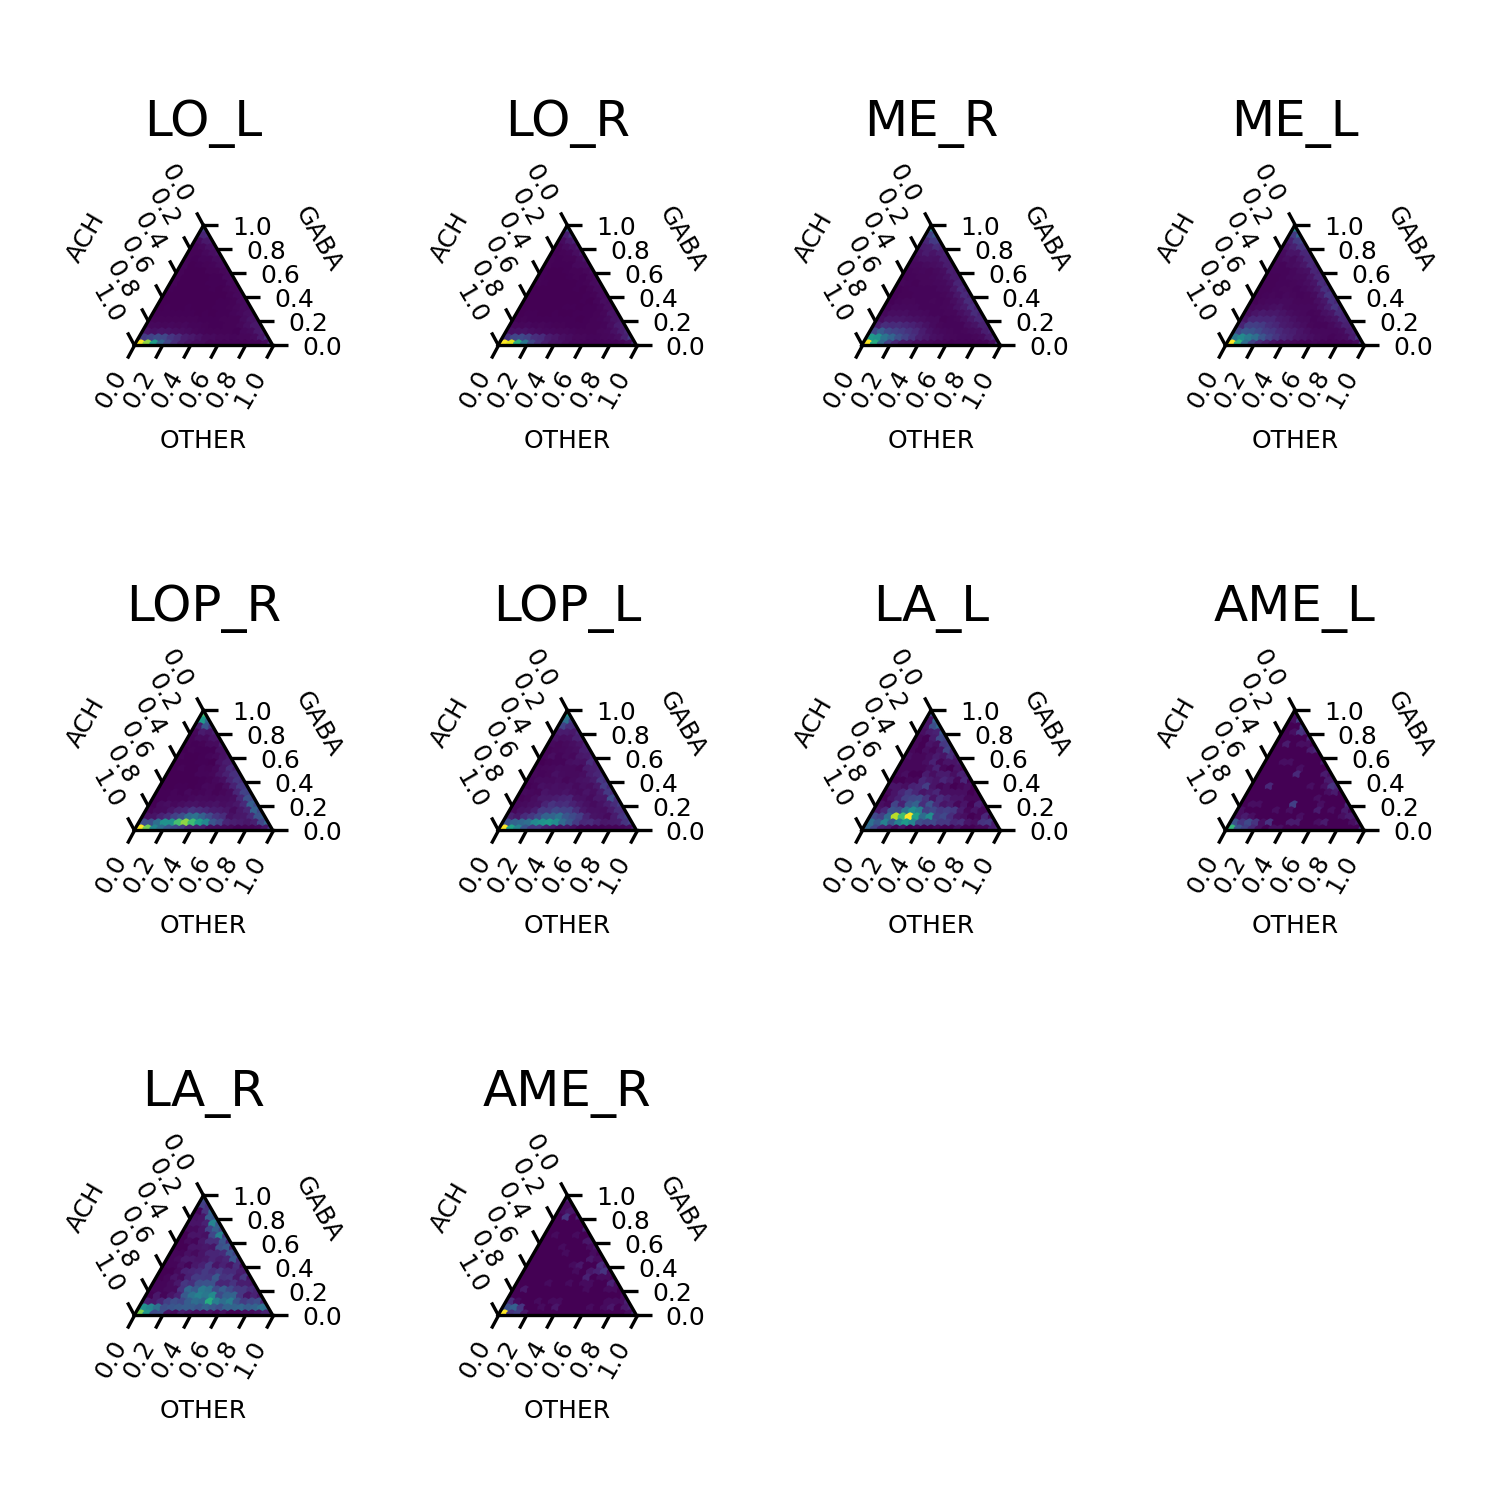

In [21]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Optic Lobe.png")
Image(filename, width = 600)

#### Lateral Horn

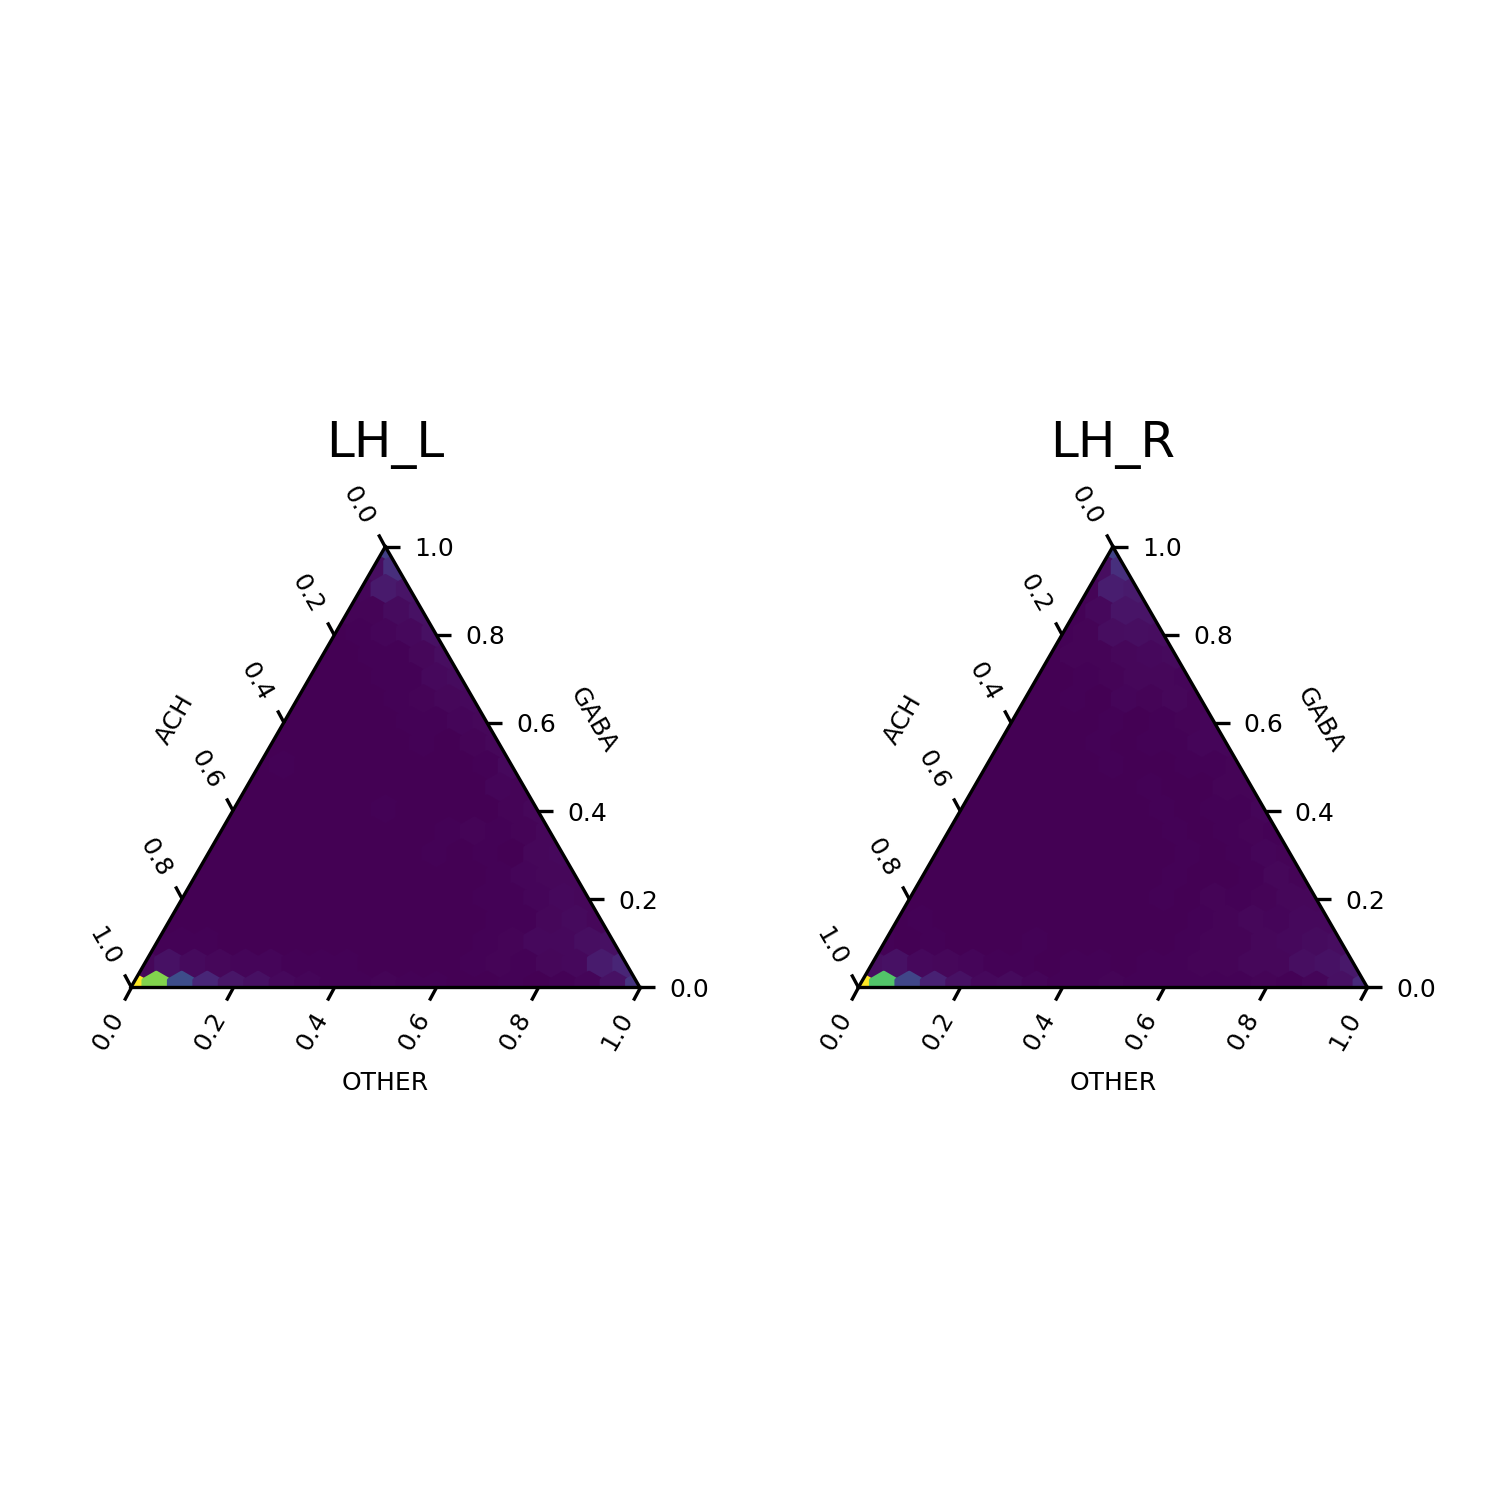

In [23]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Lateral Horn.png")
Image(filename, width = 600)

#### Periesophageal Neuropils

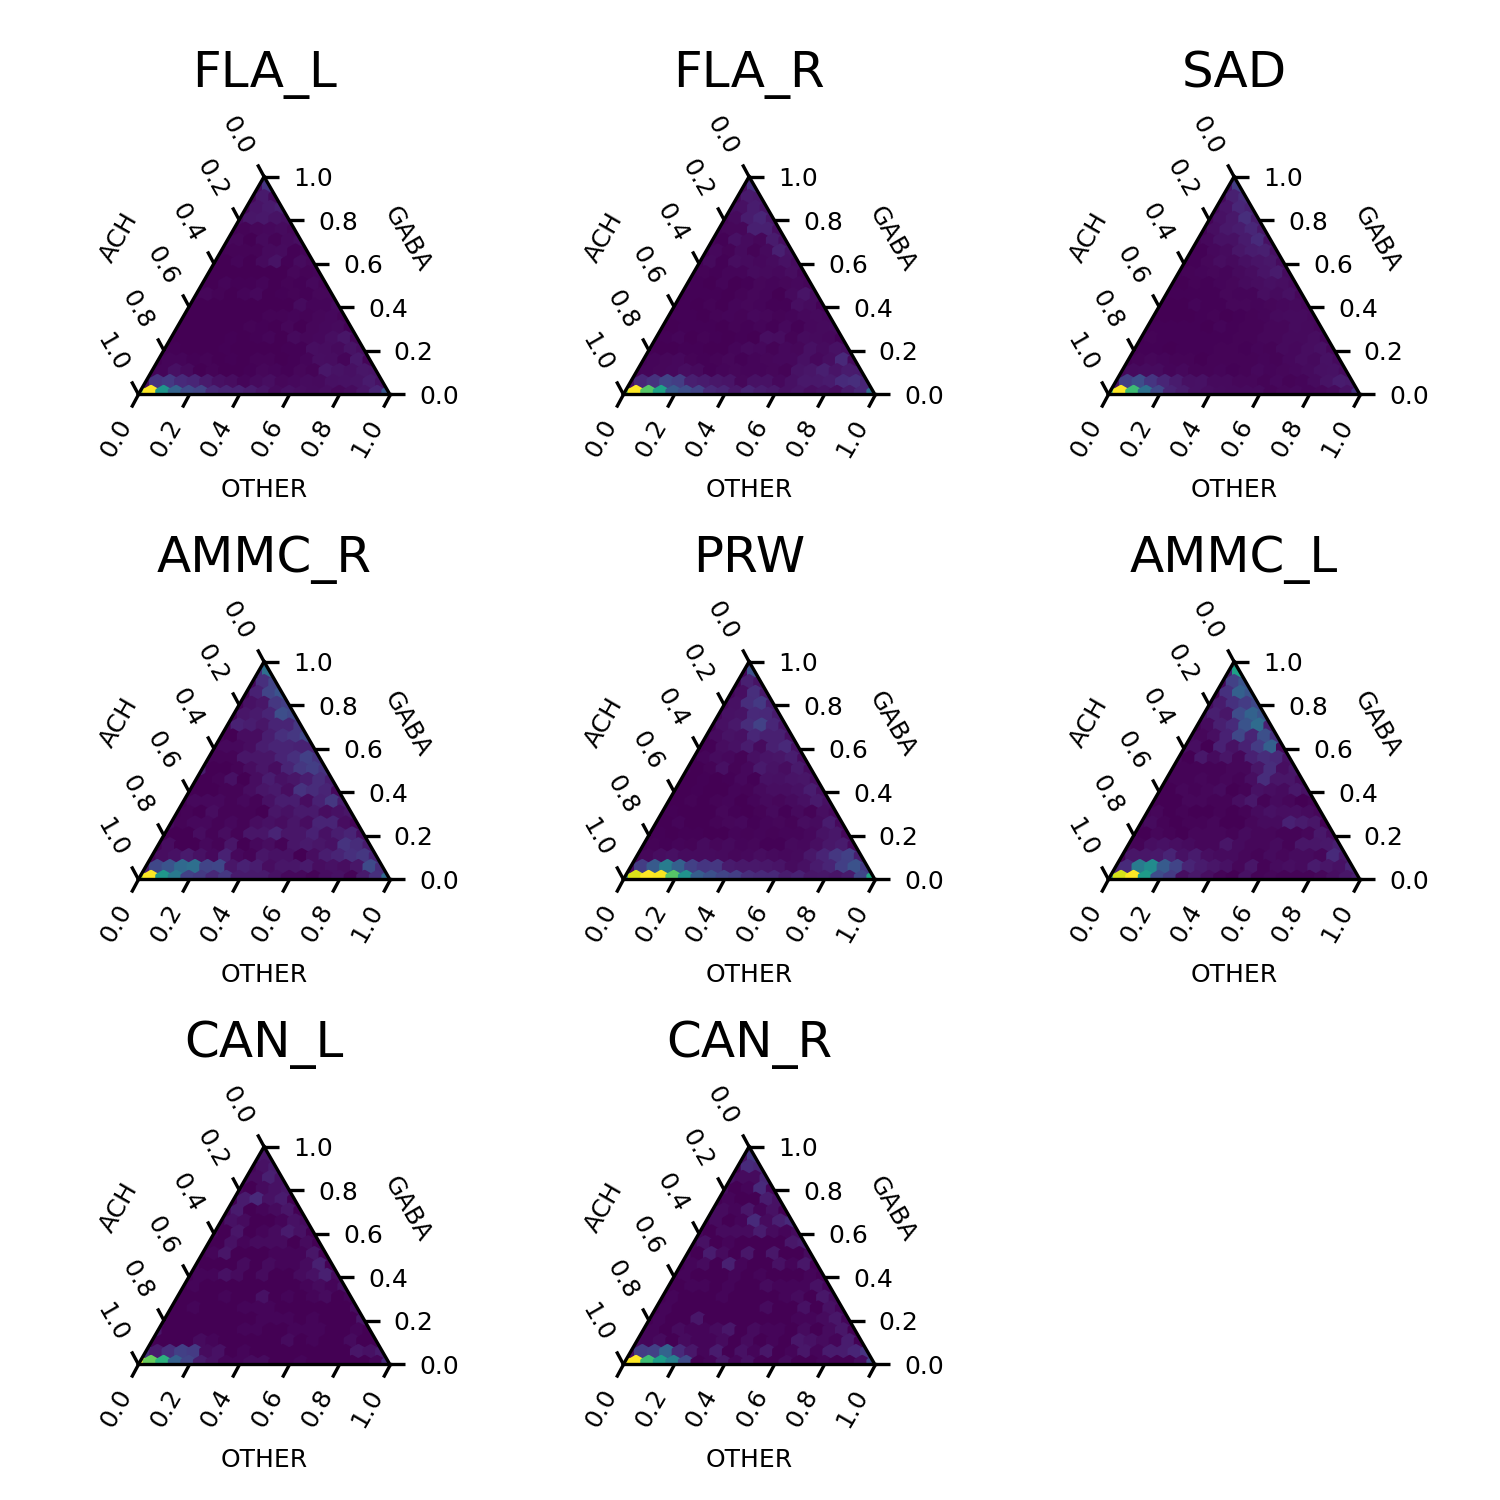

In [25]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Periesophageal Neuropils.png")
Image(filename, width = 600)

#### Inferior Neuropils

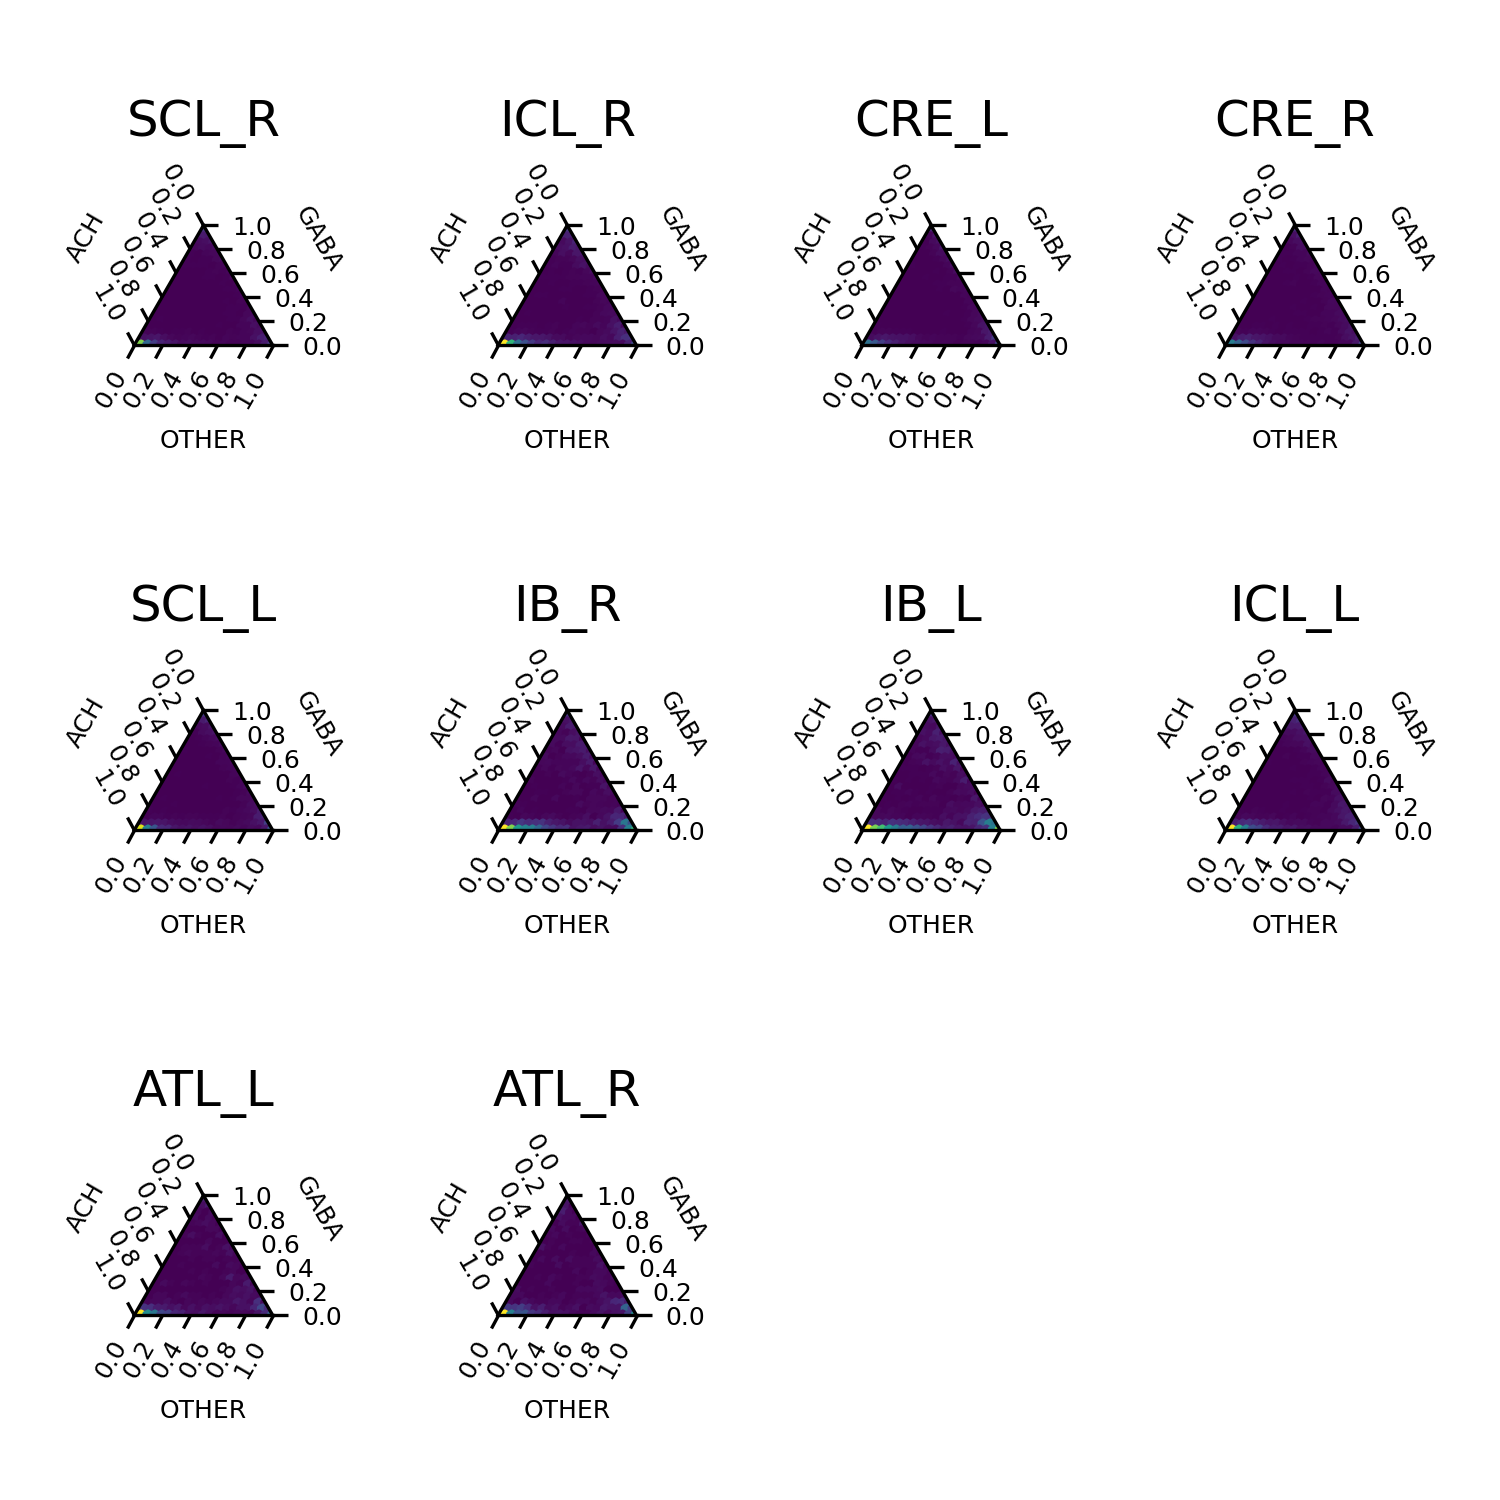

In [27]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Inferior Neuropils.png")
Image(filename, width = 600)

#### Ventromedial Neuropils

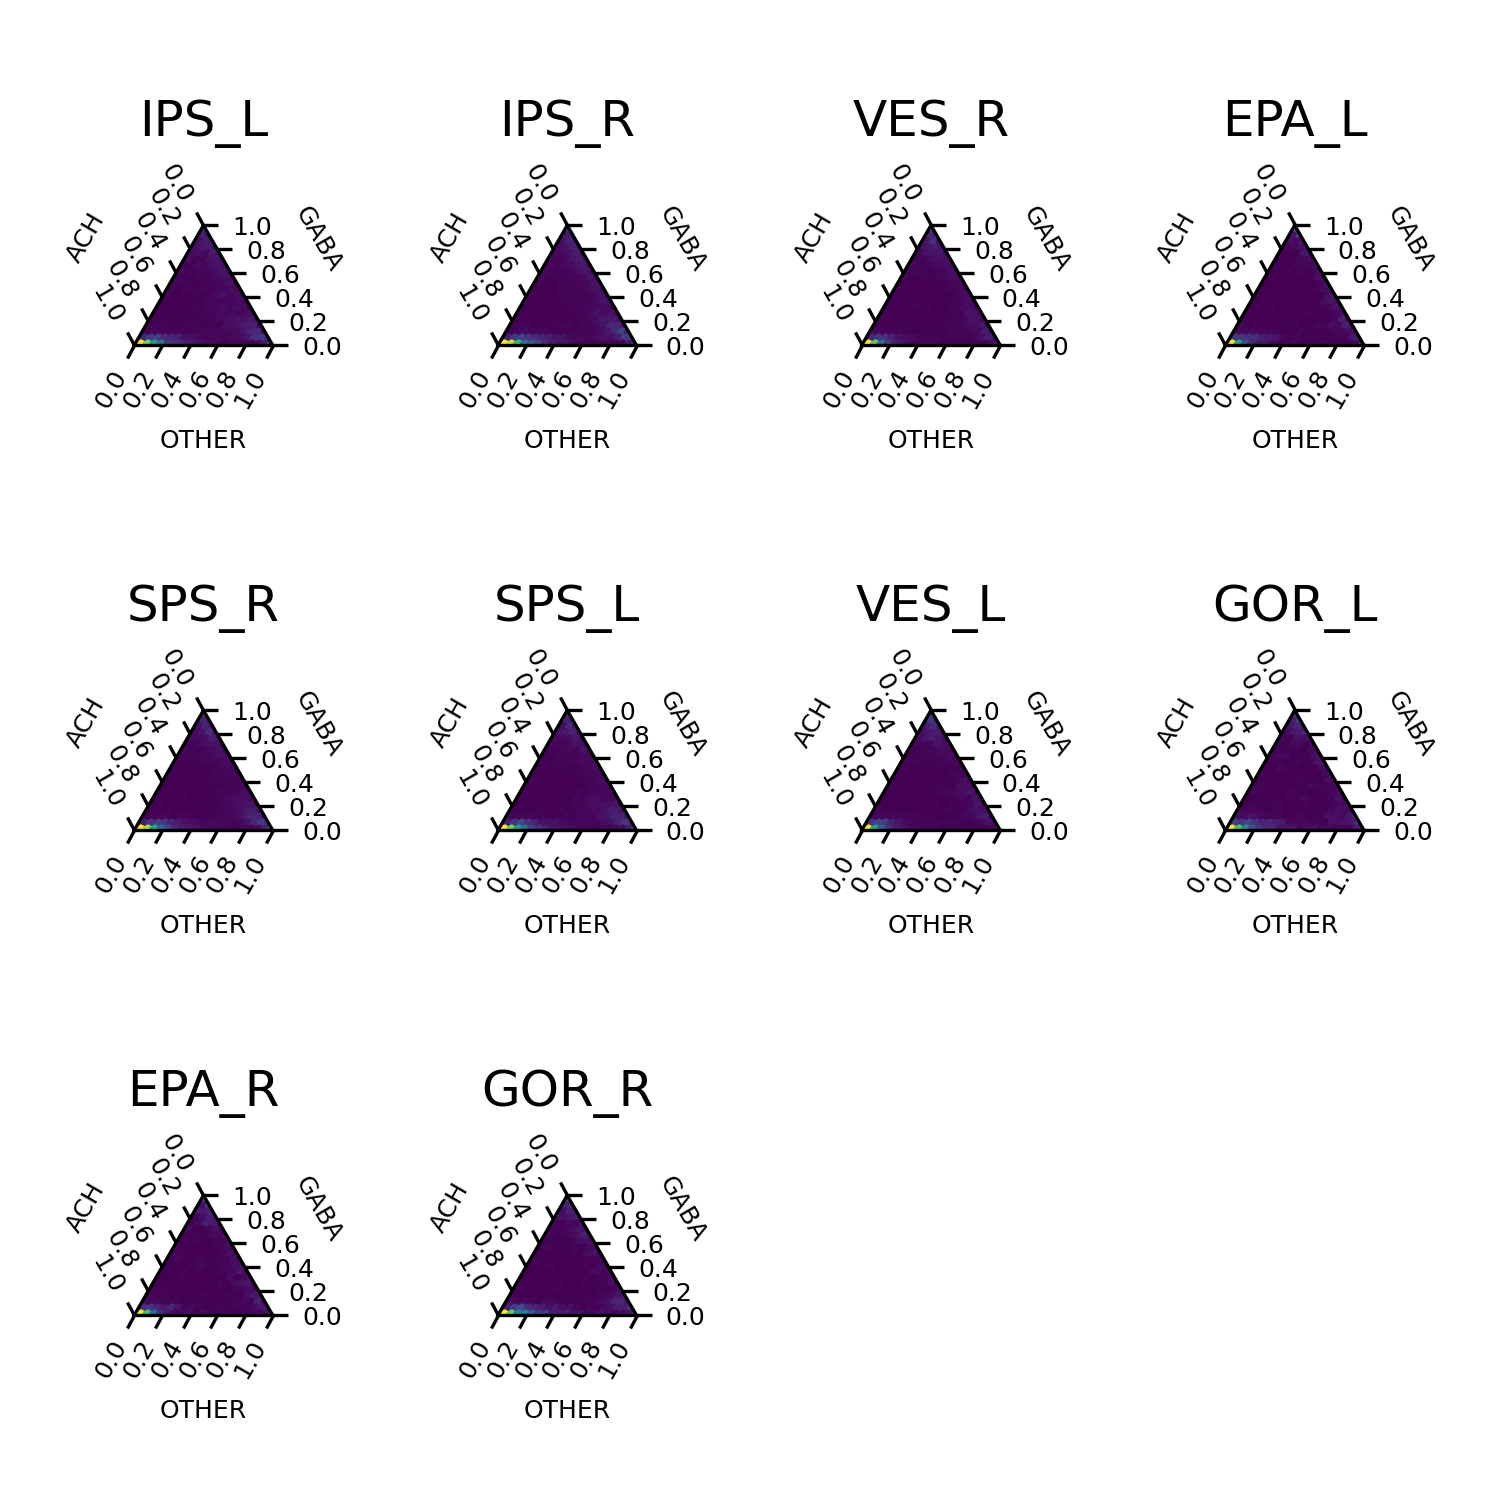

In [29]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Ventromedial Neuropils.png")
Image(filename, width = 600)

#### Mushroom Body

TODO: investigate why nothing appears for this region

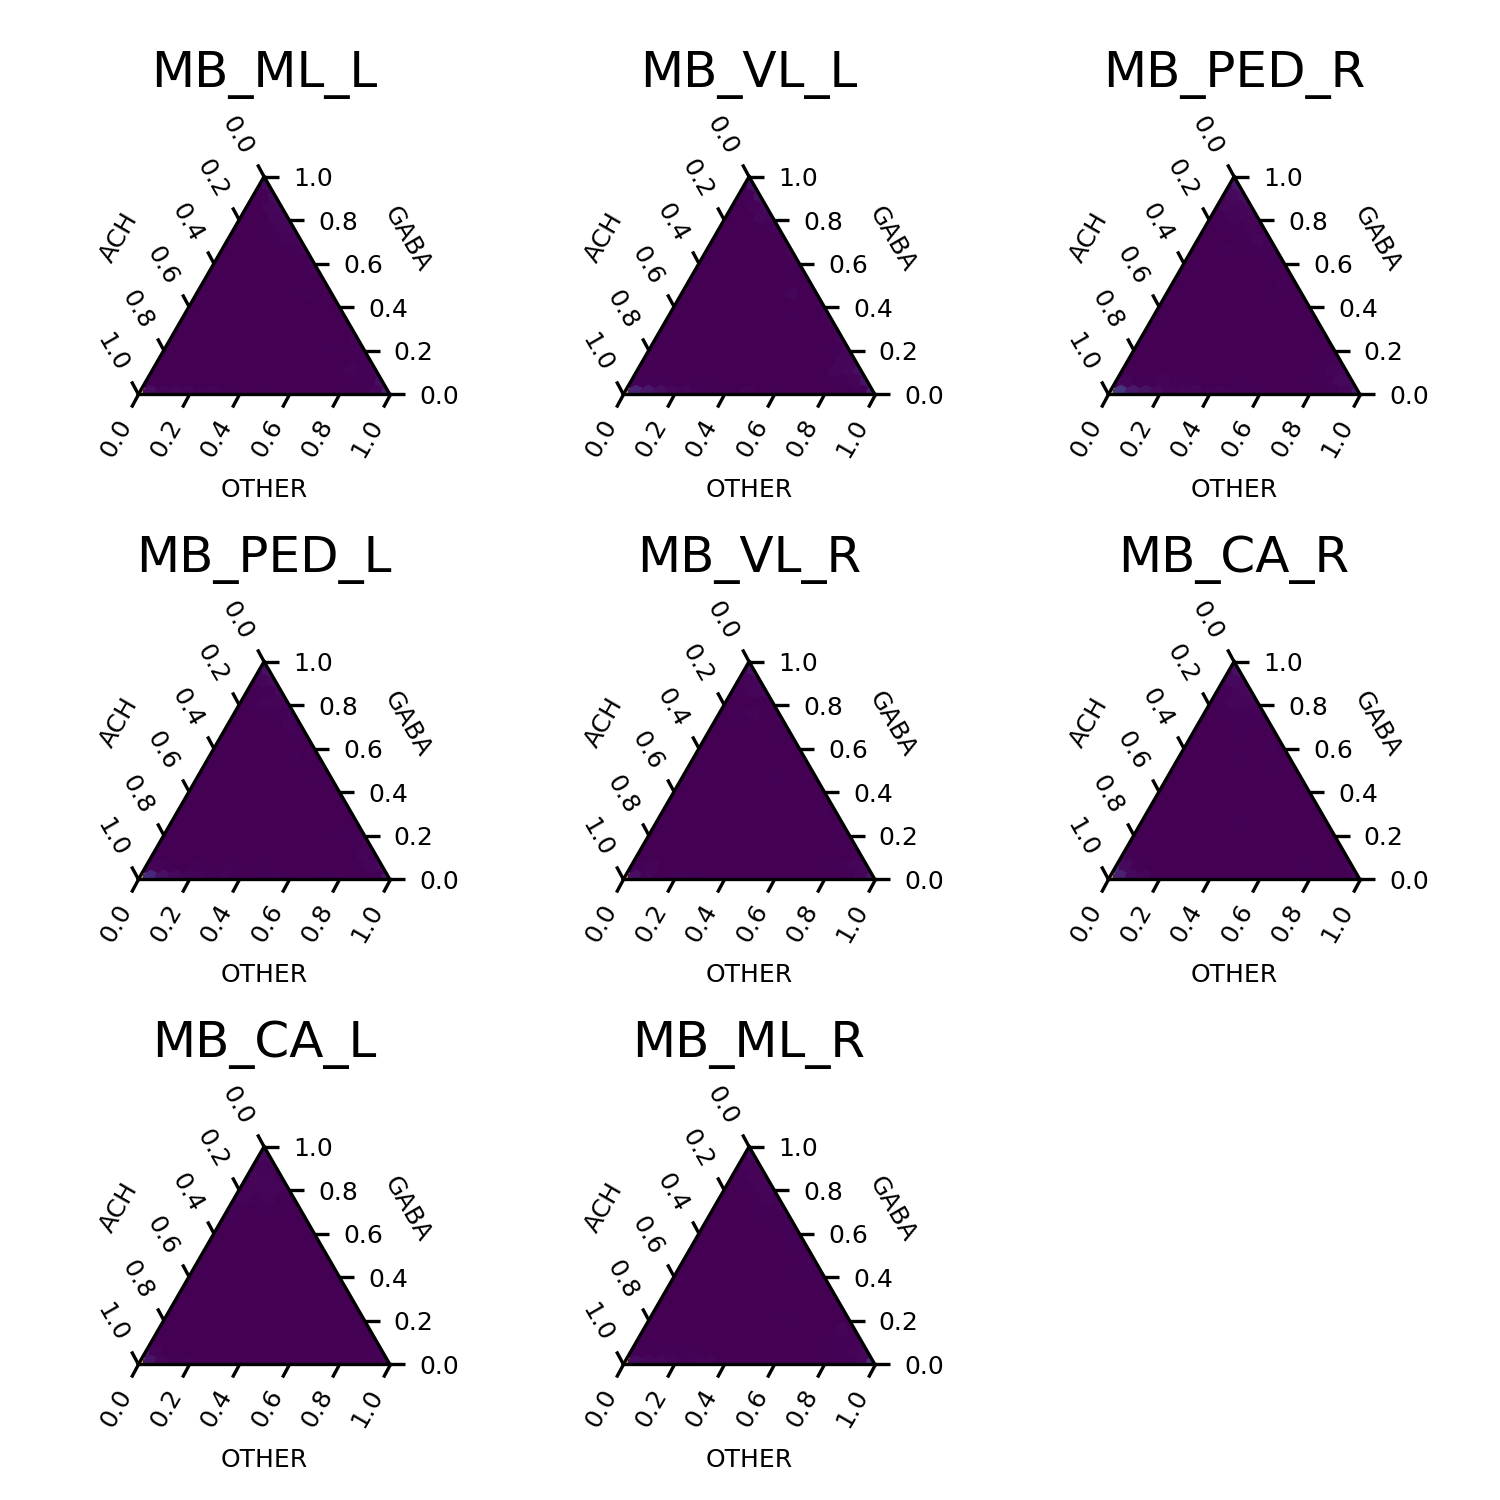

In [31]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Mushroom Body.png")
Image(filename, width = 600)

#### Antennal Lobe

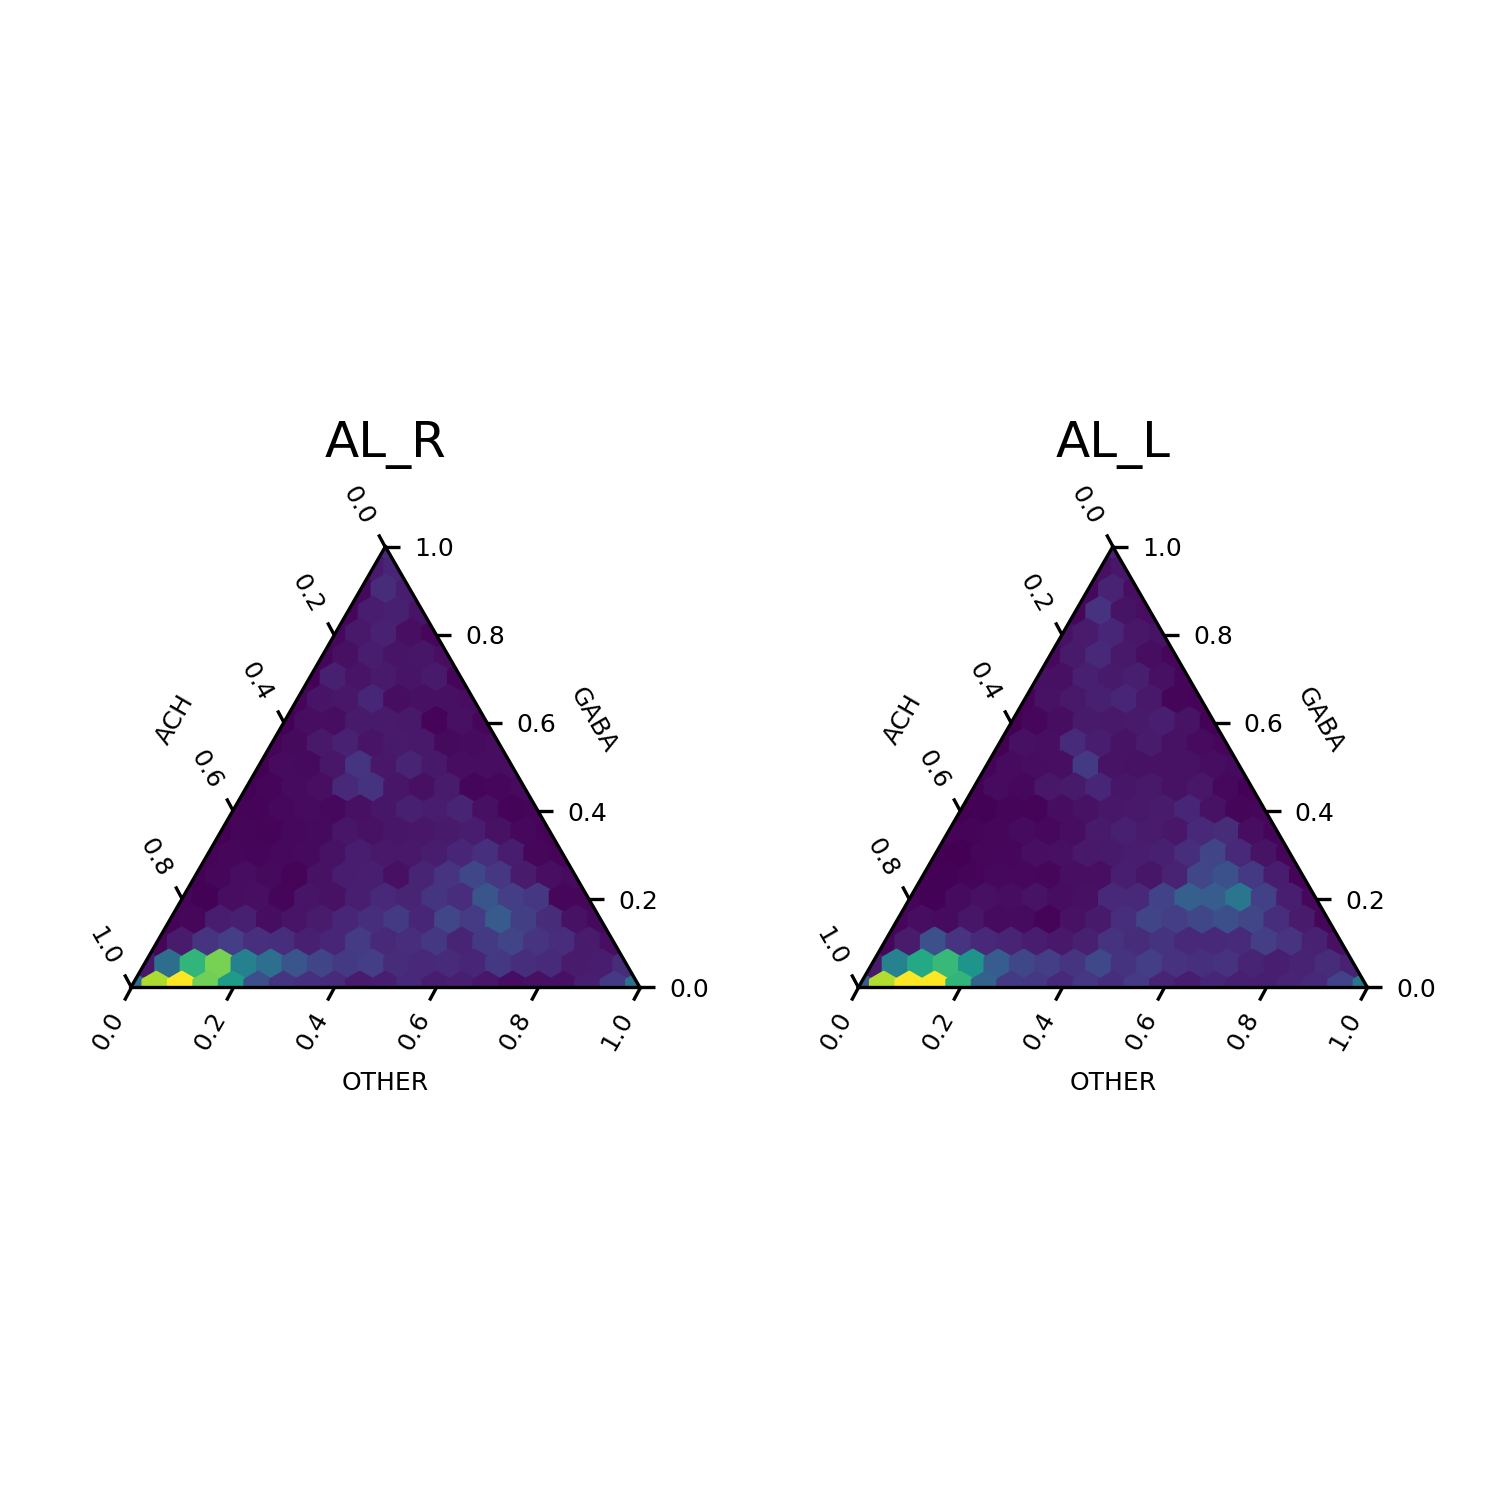

In [33]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Antennal Lobe.png")
Image(filename, width = 600)

#### Superior Neuropils

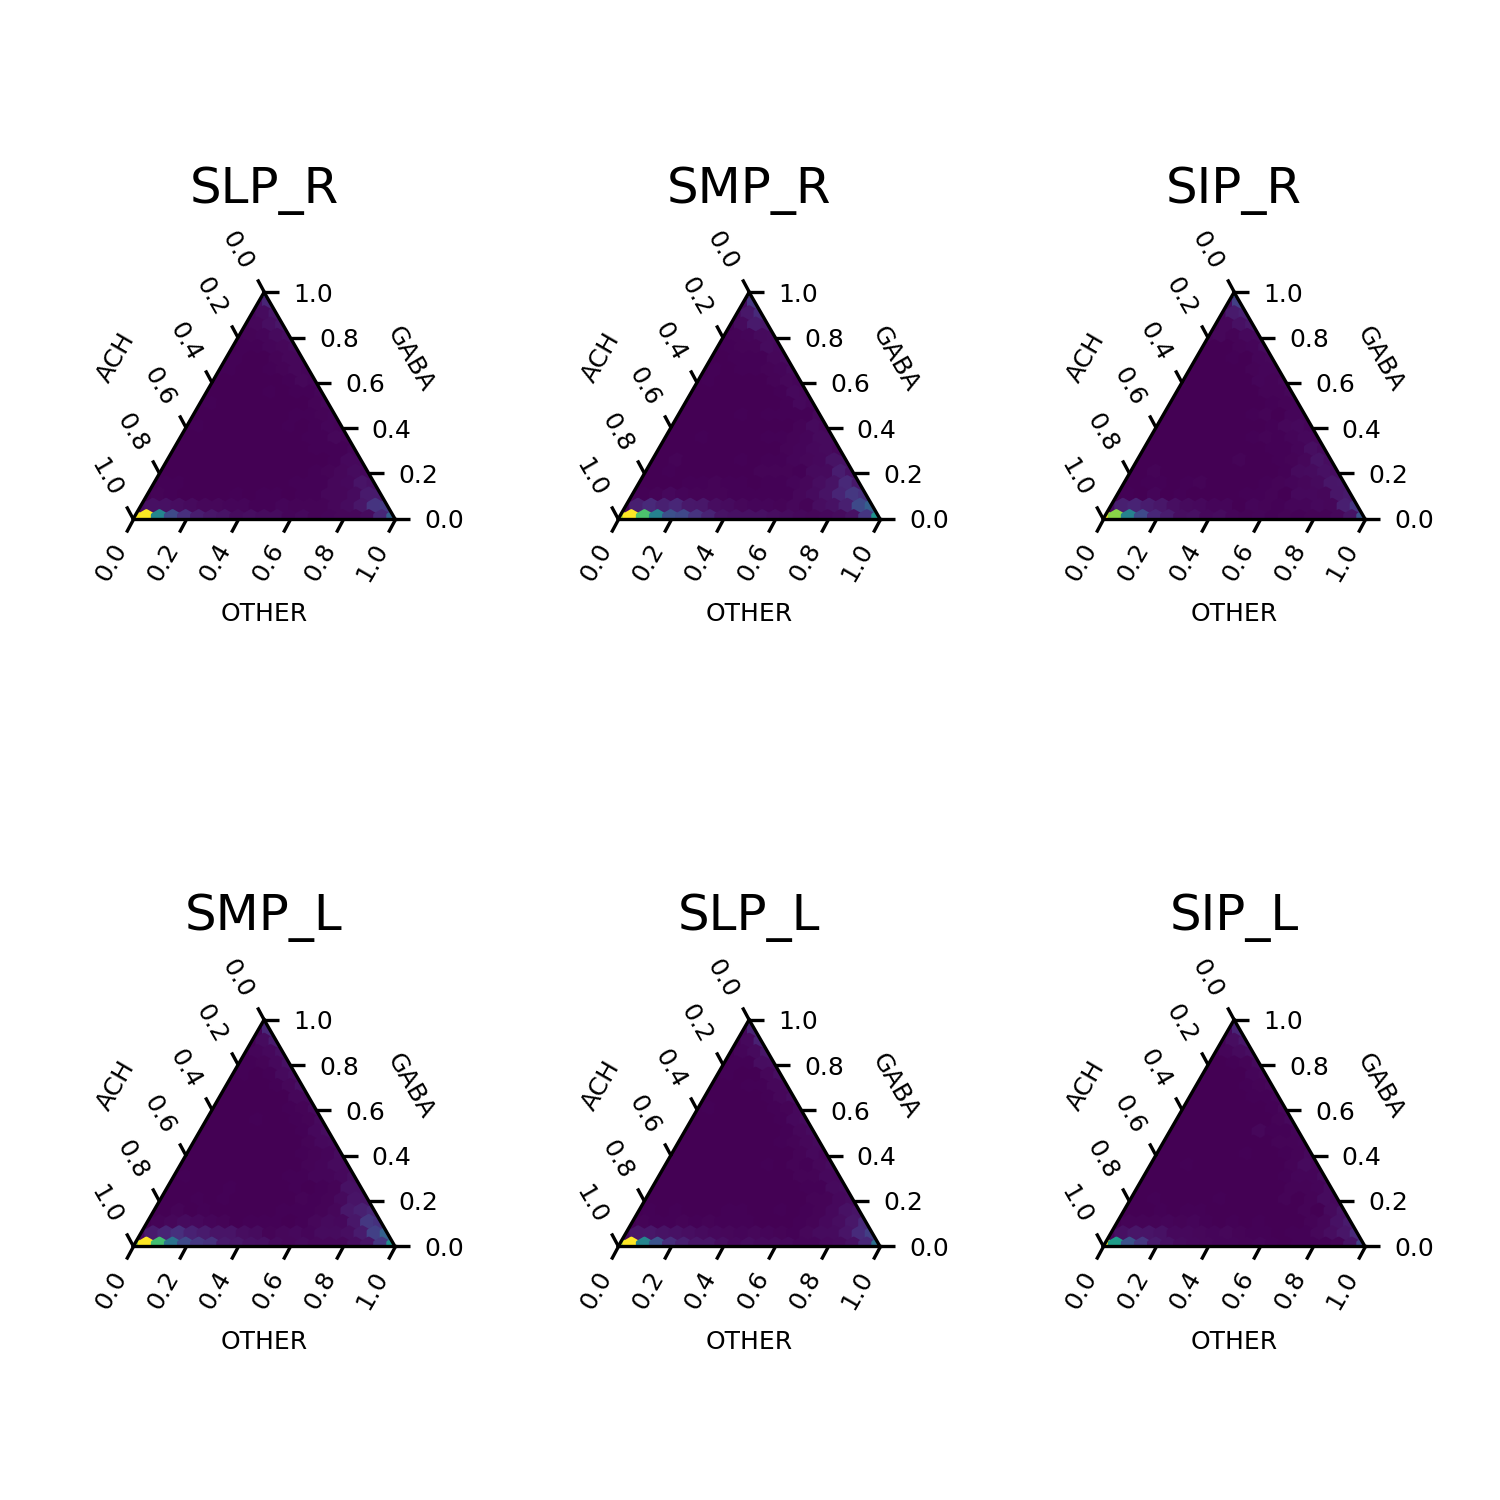

In [35]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Superior Neuropils.png")
Image(filename, width = 600)

#### Ventrolateral Neuropils

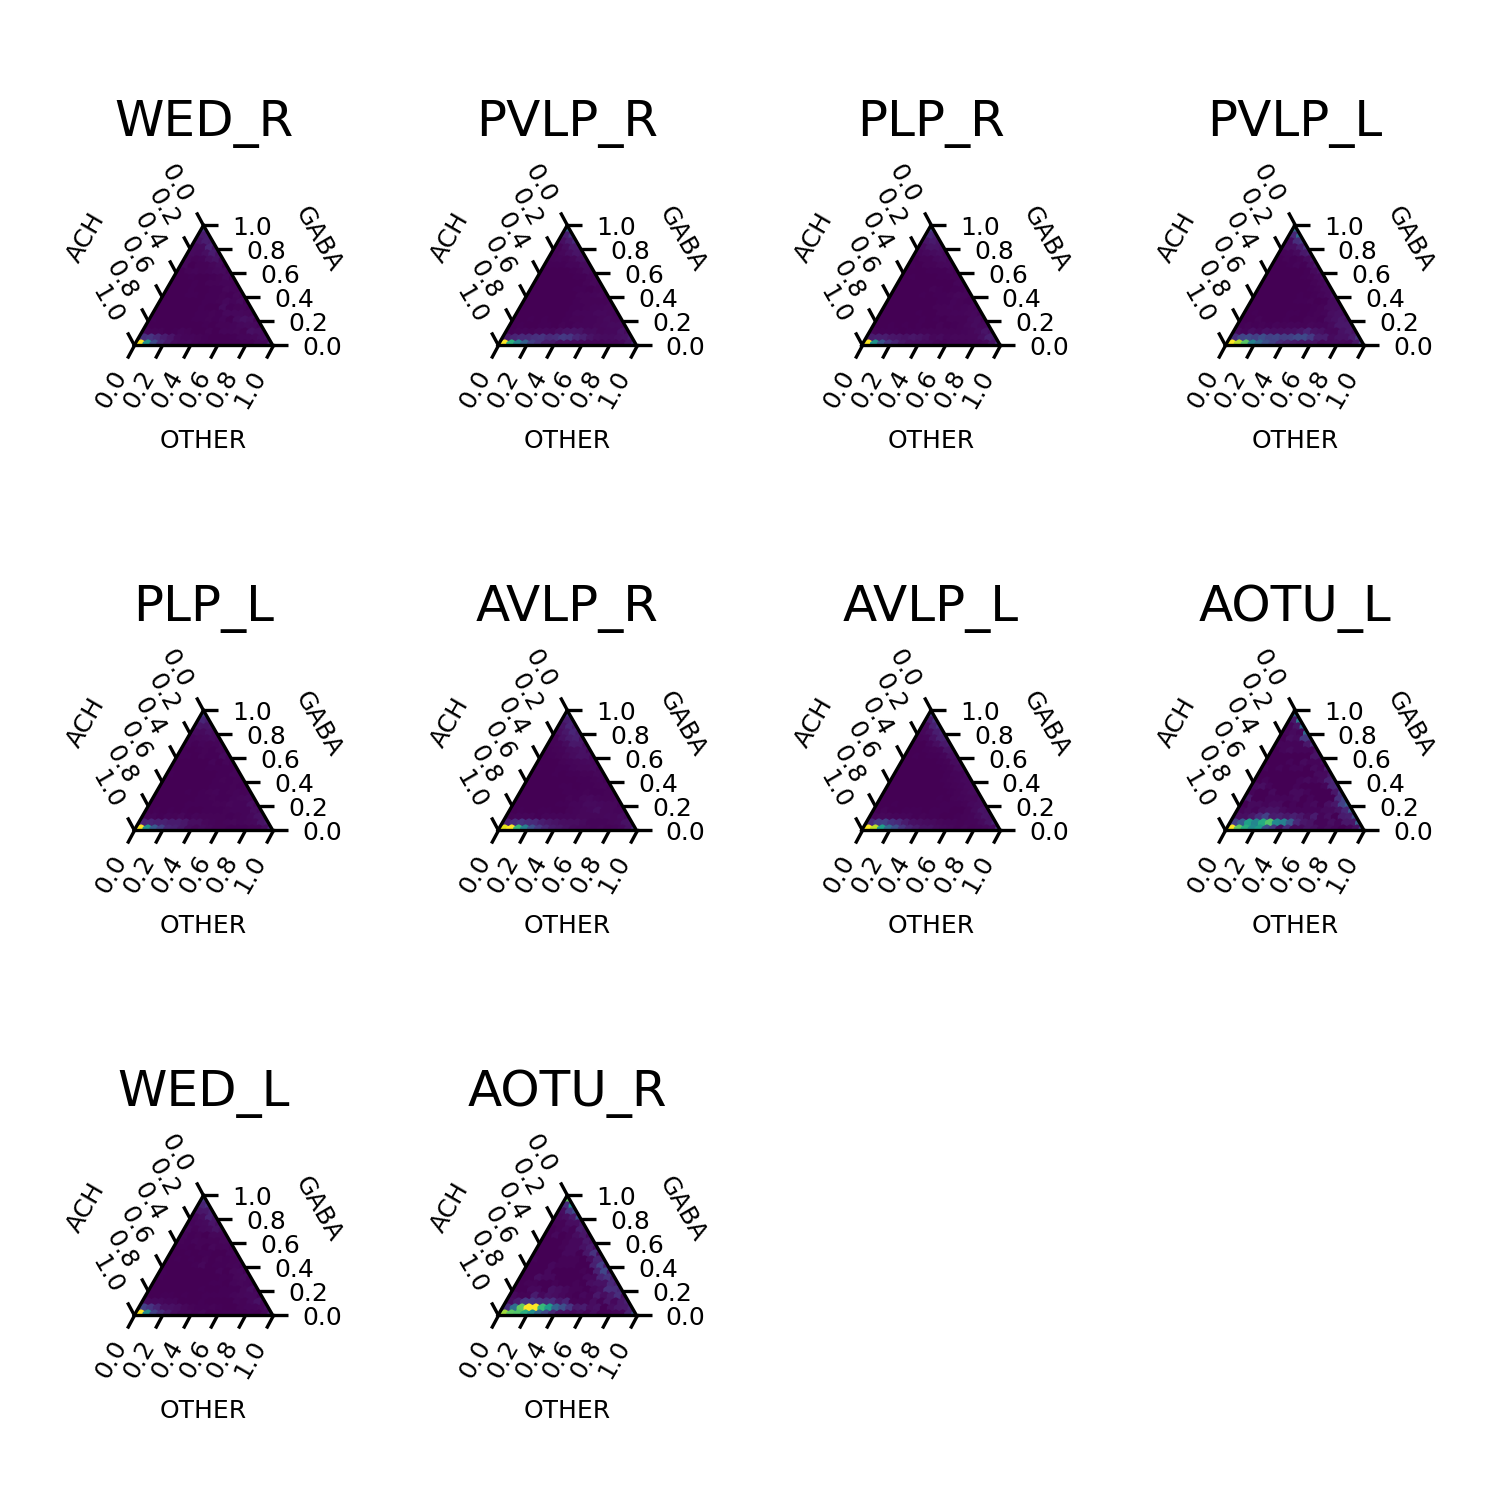

In [37]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Ventrolateral Neuropils.png")
Image(filename, width = 600)

#### Central Complex

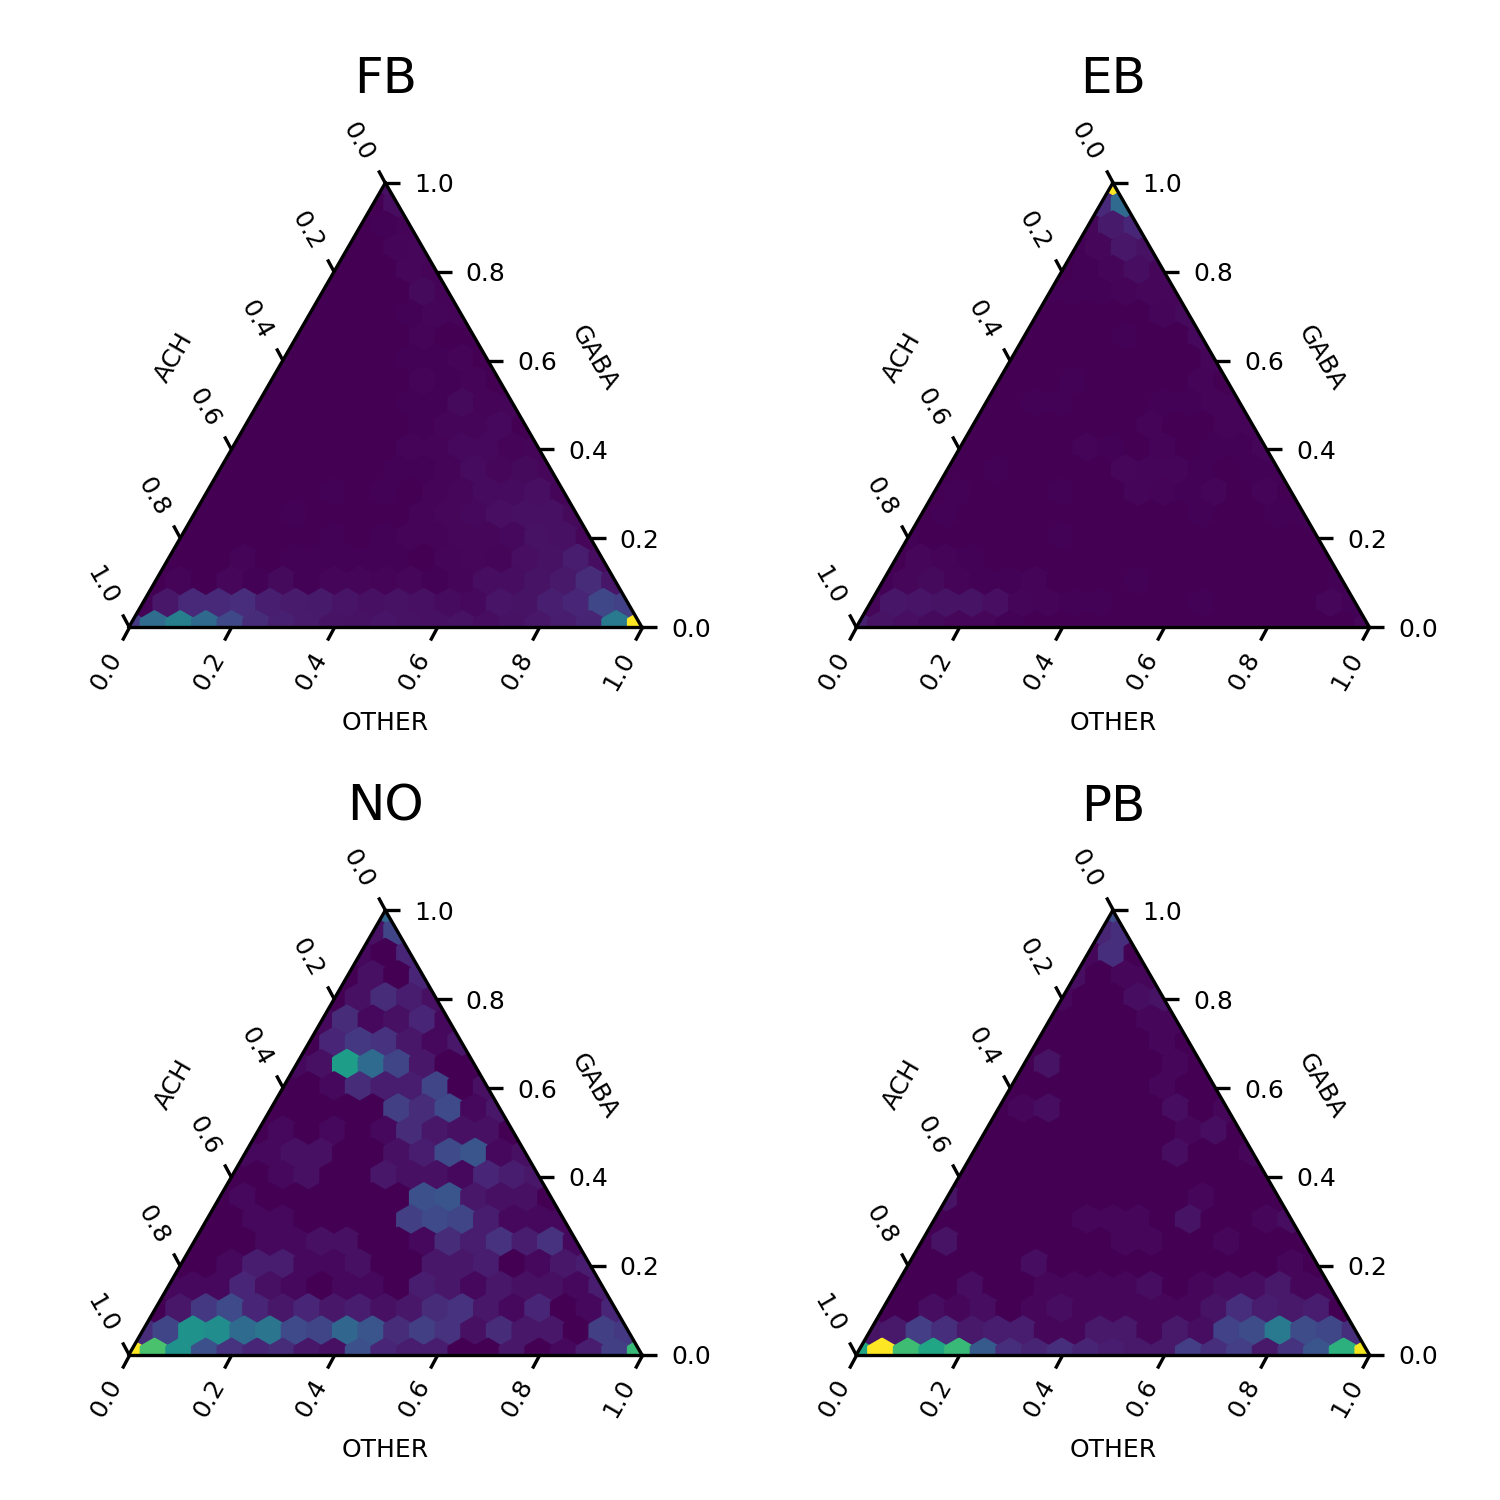

In [39]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Central Complex.png")
Image(filename, width = 600)

#### Gnathal Ganglia

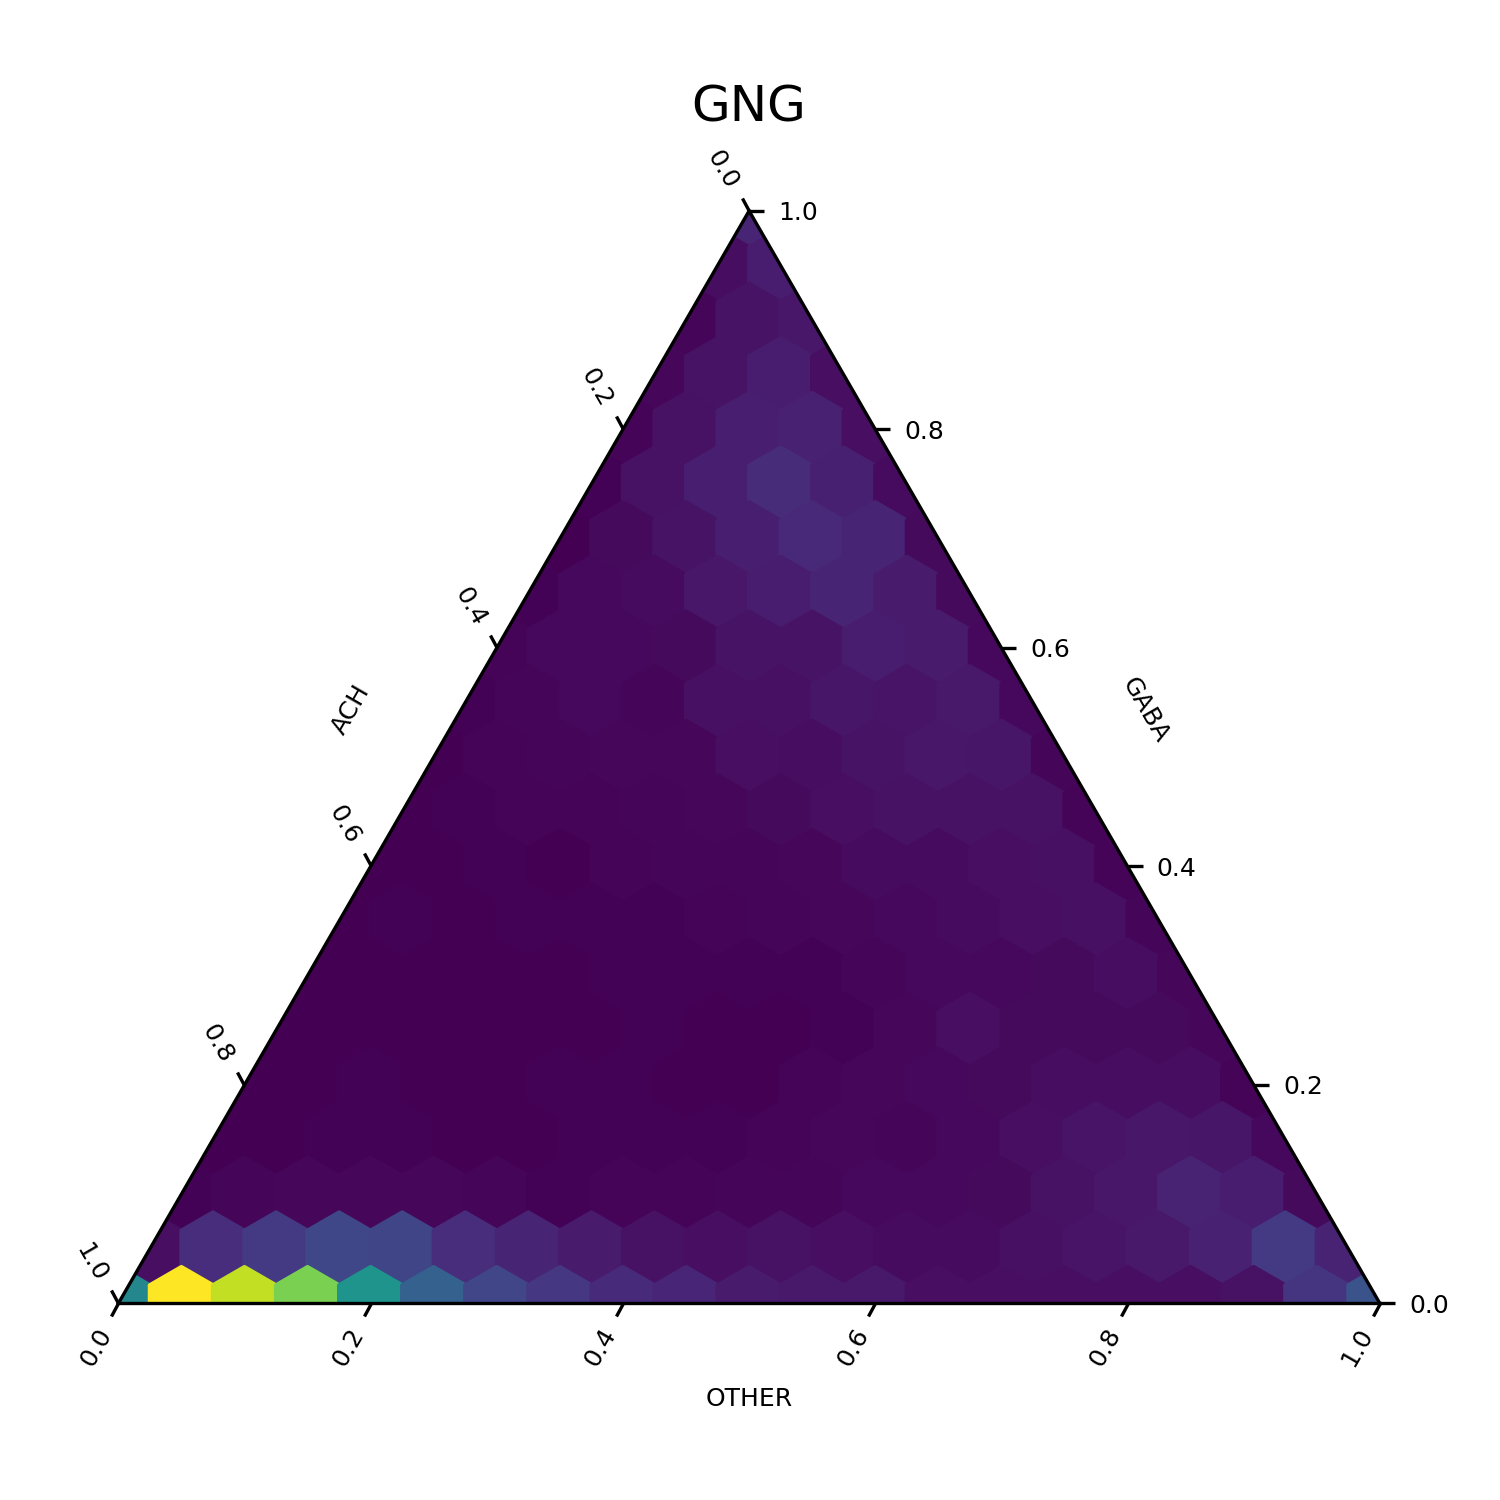

In [41]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Gnathal Ganglia.png")
Image(filename, width = 600)

#### Ocelli

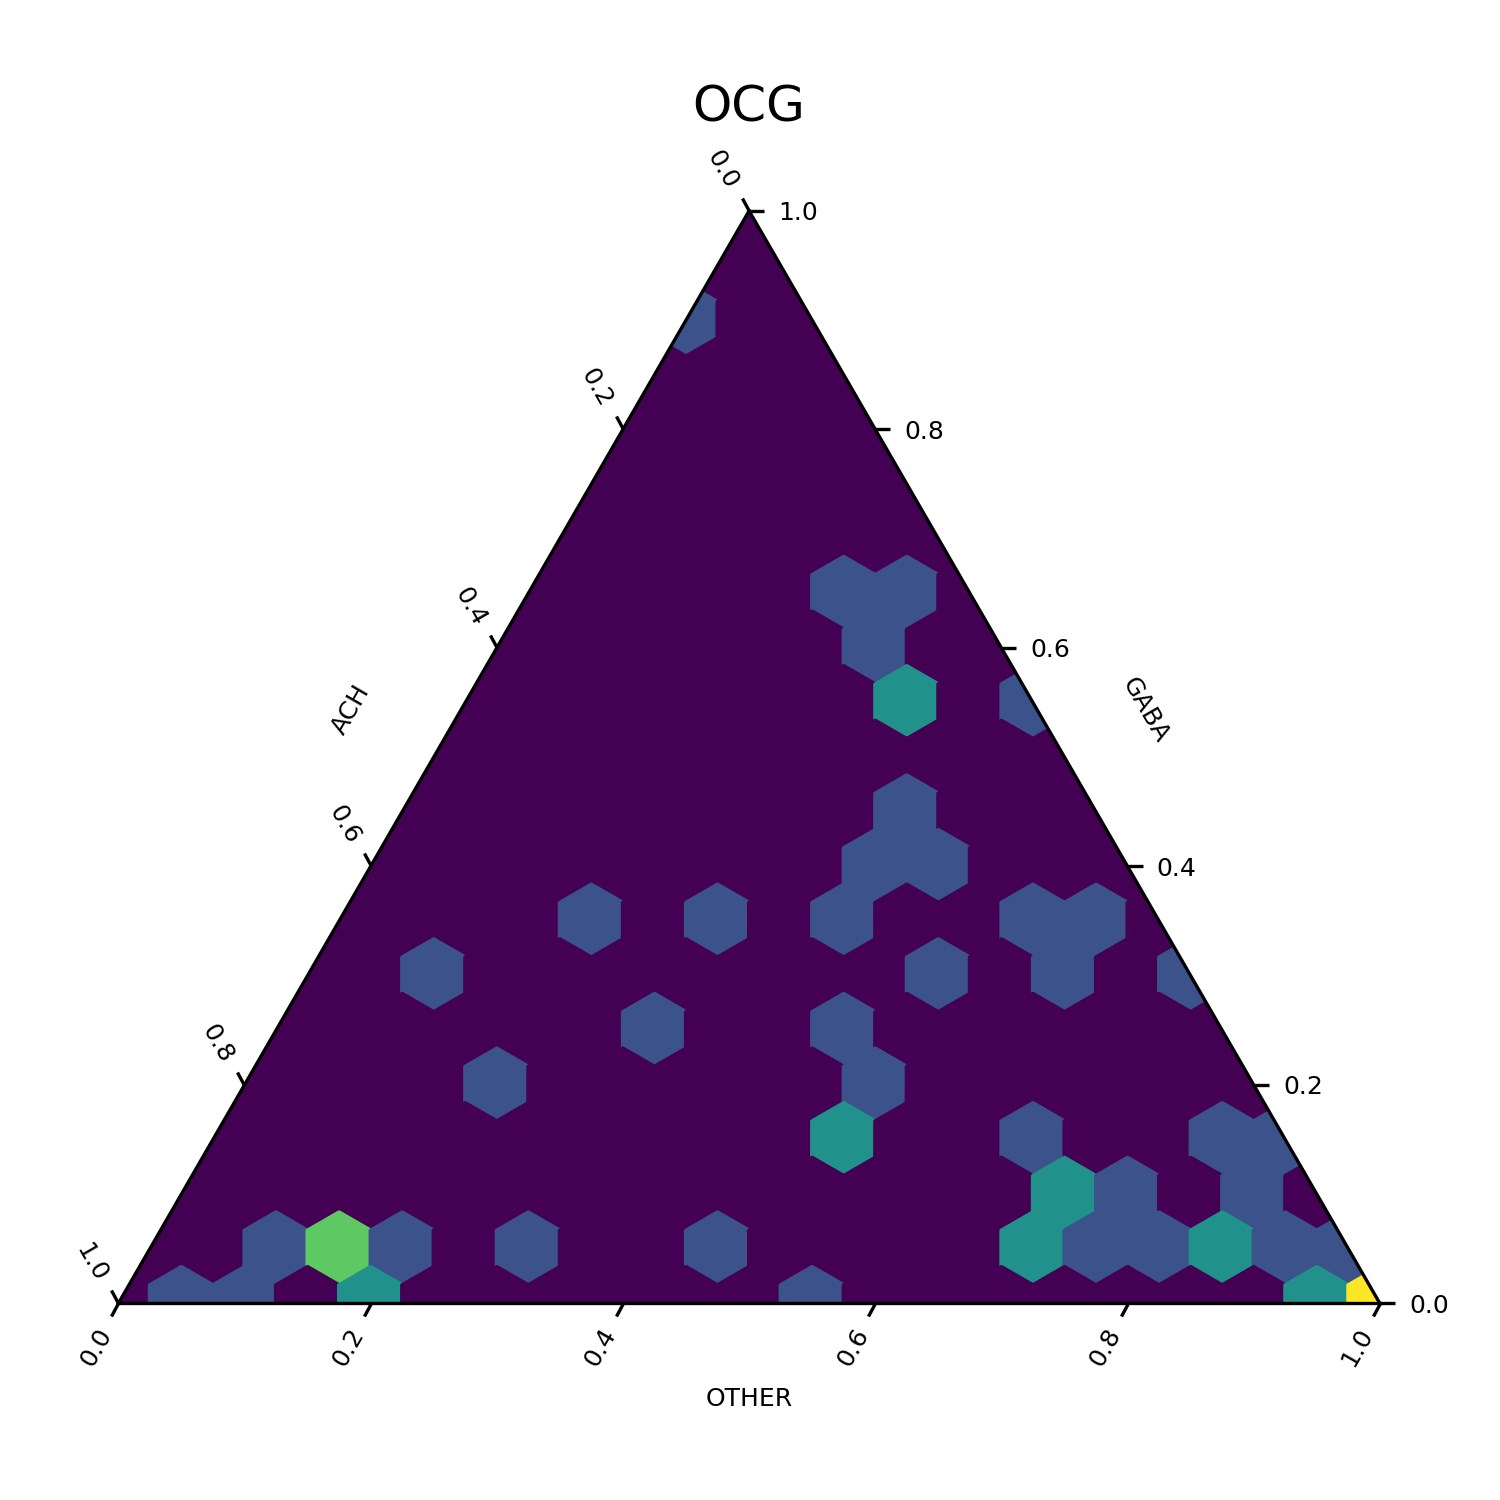

In [43]:
filename = os.path.join(OUTDIR, f"Neuropil Distributions Ocelli.png")
Image(filename, width = 600)

## Stage 4: Statistical Analysis

### Neurotransmitter Probabilities Across Different Brain Regions

I want to know whether neurotransmitter probabilities are different between neuropils. Because probabilities are a form of compositional data (the sum of the variables is 1, and each variable is bounded between 0 and 1), the Dirichlet distribution is suitable. This statistical analysis is a simple one based on average synapse probabilities within neuropils. A more statistically robust method would involve using the 'other' column to calculate the ranges of excitatory and inhibitory probabilities for each synaptic connection, then running a statistical analysis that can handle comparing range values within a bounded interval, e.g., Bayesian Dirichlet regression with interval priors. The Dirichlet function I used can only operate on points, not ranges. There does not appear to be an out-of-box Dirichlet regression function in any Python libraries, so I must use R.

### Run statistical_analysis.R

Unfortunately I did not complete this section in time.